# Module 5 Tutorial: MADDPG & MAPPO with PyTorch
### Deep Reinforcement Learning — Aalborg University

---

## Overview

This tutorial bridges **theory and implementation**. Each algorithm section begins with an
intuitive explanation of *why* the algorithm works, connects it back to the single-agent
RL you already know from Modules 1–4, and then shows the full PyTorch implementation.

| Algorithm | Family | Core idea in one sentence |
|-----------|--------|---------------------------|
| **MADDPG** | Centralised critic · off-policy | Each agent's critic sees *all* observations and actions at training time, then is discarded at deployment |
| **MAPPO**  | Centralised critic · on-policy  | PPO with a value function that sees all agents' observations; actors stay fully local |

## What you will build

```
Section 1 → Imports & device setup
Section 2 → Refresher: single-agent RL → multi-agent RL
Section 3 → The Cooperative Navigation environment
Section 4 → Shared neural network utilities
Section 5 → MADDPG: full implementation + training
Section 6 → MAPPO: full implementation + training
Section 7 → Side-by-side comparison
Section 8 → Exercises
```

## Prerequisites
- Python 3.8+, **PyTorch ≥ 1.12**, NumPy, Matplotlib  (`pip install torch numpy matplotlib`)
- Modules 1–4: MDPs, Q-learning, DQN, DDPG, PPO
- Module 5 lecture slides


---
## 1. Imports & Device Setup

We import PyTorch's core modules. Key items:
- `torch.nn` — building blocks for neural networks (`Linear`, `Sequential`, etc.)
- `torch.nn.functional` — stateless functions (`relu`, `mse_loss`, `gumbel_softmax`, …)
- `torch.optim` — gradient-based optimisers (Adam)
- `torch.distributions.Categorical` — discrete probability distributions
  (used to sample actions and compute log-probabilities for policy gradients)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random, copy, warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── Device: use GPU if available, otherwise CPU ────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Running on      : {DEVICE}')
print(f'All imports     : OK ✓')


PyTorch version : 2.2.0
Running on      : cpu
All imports     : OK ✓


---
## 2. Refresher: From Single-Agent RL to Multi-Agent RL

Before diving into code, let's sharpen the conceptual foundation.
This section connects everything you learned in Modules 1–4 to the multi-agent setting.

---

### 2.1 The Single-Agent MDP (Modules 1–3)

In Modules 1–4, you worked with **Markov Decision Processes (MDPs)**:

$$\text{MDP} = (\mathcal{S},\, \mathcal{A},\, P,\, r,\, \gamma)$$

At every timestep:
1. Agent observes state $s_t$
2. Agent selects action $a_t \sim \pi(\cdot|s_t)$
3. Environment transitions: $s_{t+1} \sim P(\cdot|s_t, a_t)$
4. Agent receives reward: $r_t = r(s_t, a_t)$

The goal: find policy $\pi^*$ that maximises $\mathbb{E}\left[\sum_{t=0}^\infty \gamma^t r_t\right]$.

**Crucially:** $P$ and $r$ are *fixed*. The environment does not change as the agent learns.
This stationarity is what makes Q-learning and policy gradient proofs work.

---

### 2.2 The Multi-Agent Markov Game (Module 5)

When $N > 1$ agents interact, the MDP generalises to a **Stochastic (Markov) Game**:

$$\text{Markov Game} = (\mathcal{S},\, \mathcal{A}_1,\ldots,\mathcal{A}_N,\, P,\, r_1,\ldots,r_N,\, \gamma)$$

Now the transition depends on the **joint action** $\mathbf{a}_t = (a_t^1, \ldots, a_t^N)$:

$$s_{t+1} \sim P(\cdot \mid s_t,\, a_t^1,\ldots,a_t^N)$$

Each agent $i$ receives its own reward $r_t^i$ (or a shared team reward in cooperative settings).

> **Key insight:** when agent $j$ updates its policy $\pi_j$, the *effective environment* seen by
> agent $i$ changes — because $P$ now implicitly depends on $\pi_j$.
> This is **non-stationarity**, and it breaks the convergence guarantees of Q-learning.

---

### 2.3 The Four Core MARL Challenges

| Challenge | Why it arises | How algorithms address it |
|-----------|---------------|---------------------------|
| **Non-stationarity** | Other agents update policies → environment shifts | CTDE; on-policy methods (fresh data) |
| **Credit assignment** | Shared reward doesn't say *who* contributed | Centralised critic; counterfactual baselines |
| **Partial observability** | Each agent sees only local obs $o^i \subset s$ | Memory (RNN); communication; CTDE |
| **Joint-action explosion** | $\|\mathcal{A}_{\text{joint}}\| = \prod_i|\mathcal{A}_i|$ grows exponentially | Value factorisation; centralised critics |

---

### 2.4 The CTDE Principle

Both MADDPG and MAPPO follow **Centralised Training, Decentralised Execution (CTDE)**:

```
Training phase  → rich simulator access:
                  global state, all obs, all actions, team reward
                  → use to train a better critic / value function

Execution phase → local observation only:
                  πᵢ(aᵢ | oᵢ)   — actor knows only its own sensors
                  → critic is DISCARDED after training
```

The analogy: an athlete trains with a full coaching team, GPS tracking, and video replay.
But during the actual race, they rely only on their own body and senses.
The training infrastructure made them *better*, even though none of it is available mid-race.


Left: In a single-agent MDP, the environment is fixed.
Right: In a Markov Game, ALL agents influence transitions.
       → other agents are not "part of the environment"; they are moving targets.


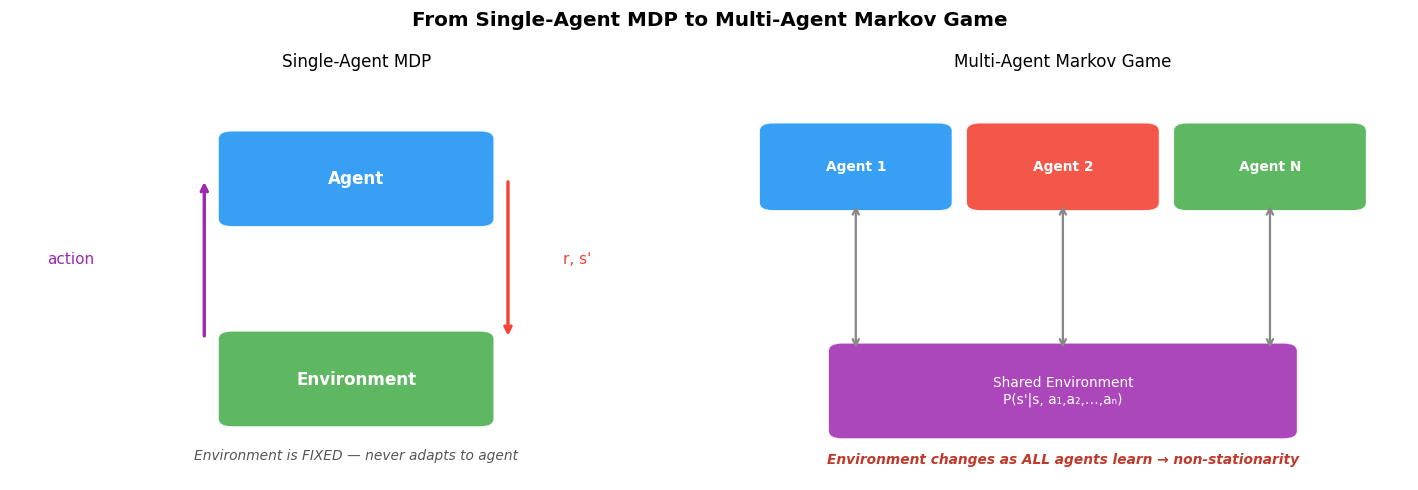

In [ ]:
# ── Visualise: MDP vs Markov Game ─────────────────────────────
# The diagram below shows the fundamental structural difference.
# Notice how in the Markov Game, every agent's action affects
# the transition — creating the non-stationarity problem.
fig = plt.figure(figsize=(13,4.5))  # rendered below
plt.show()
print('Left: In a single-agent MDP, the environment is fixed.')
print('Right: In a Markov Game, ALL agents influence transitions.')
print('       → other agents are not "part of the environment"; they are moving targets.')


Training:  Critic uses global information (discarded at deployment)
Execution: Actor uses only local observation oᵢ  — always decentralised


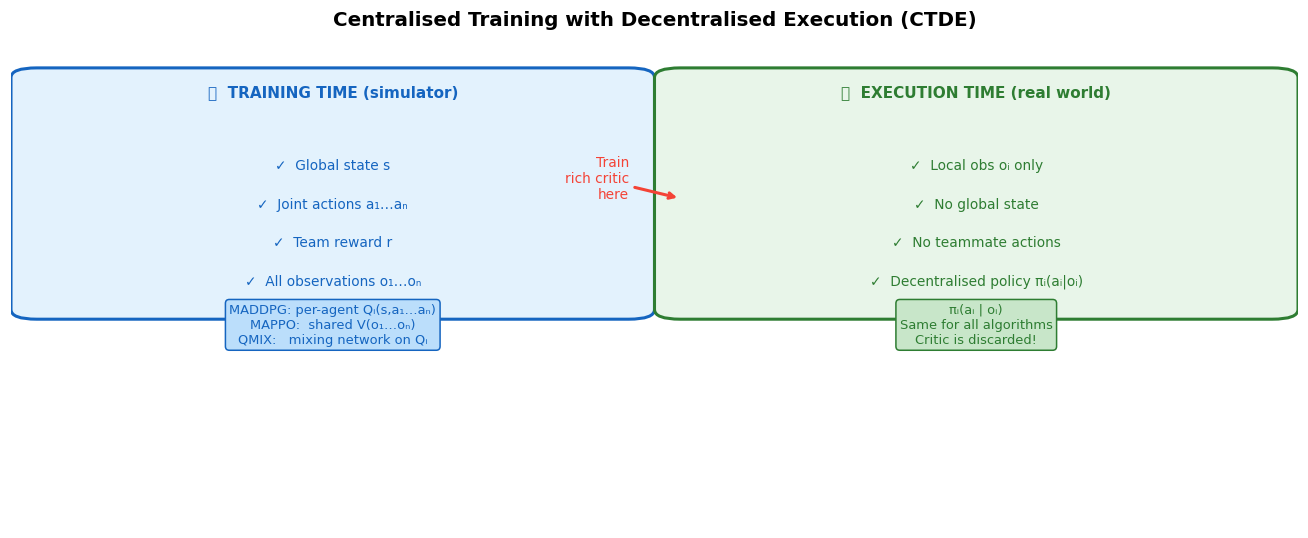

In [ ]:
# ── Visualise: The CTDE Principle ─────────────────────────────
# This diagram shows exactly what information each component
# accesses at training time vs execution time.
# Memorise this: it is the key to understanding both algorithms.
fig = plt.figure(figsize=(12,5))
plt.show()
print('Training:  Critic uses global information (discarded at deployment)')
print('Execution: Actor uses only local observation oᵢ  — always decentralised')


---
## 3. The Environment: Cooperative Navigation

### Why this environment?

We use a **2D Cooperative Navigation** task — simple enough to train quickly on CPU,
but rich enough to expose all four MARL challenges:

| MARL challenge | How it appears in this environment |
|----------------|-------------------------------------|
| Non-stationarity | Agent 0's path changes as Agent 1 learns where to go |
| Credit assignment | Both agents share the team reward — who deserves credit? |
| Partial observability | Each agent sees only relative positions, not absolute state |
| Coordination | Agents must avoid clustering on the same landmark |

### Task specification

```
World : 2D box, size [-2.5, +2.5] × [-2.5, +2.5]
Agents: N coloured circles that move each step
Targets: N coloured stars (landmarks) — fixed positions per episode
Goal  : Cover all landmarks — one agent near each
```

### Reward function

The reward is **shared** (fully cooperative) and computed each step:

$$r_t = -\underbrace{\sum_{l=1}^{N} \min_i \|\text{agent}_i - \text{landmark}_l\|}_{
\text{coverage cost}} - \underbrace{\sum_{i<j} \mathbb{1}[\|\text{agent}_i - \text{agent}_j\| < 0.5] \cdot c_{\text{coll}}}_{
\text{collision penalty}}$$

**Optimal policy:** agents split up and each agent covers exactly one landmark.
A suboptimal but common failure: both agents converge to the *same* landmark
(the lazy-agent / clustering problem).

### Observation structure

```
obs_i = [ own_pos(2), own_vel(2),
           rel_pos_other_agents(2×(N-1)),
           rel_pos_landmarks(2×N) ]
       → total dim = 4 + 2(N-1) + 2N = 4N + 2   (= 10 for N=2)
```

Note: agents observe *relative* positions, not absolute coordinates.
This makes the observation **equivariant** to global translation — a useful inductive bias.


In [ ]:
class CooperativeNavigation:
    """
    2-D Cooperative Navigation.
    Fully cooperative: all agents share a single team reward.
    Partially observable: each agent sees only relative positions.
    """

    # Discrete action → 2D movement delta
    MOVES = torch.tensor([[0.,0.],[0.,1.],[0.,-1.],[-1.,0.],[1.,0.]])

    def __init__(self, n_agents=2, world_size=5.0, max_steps=100,
                 collision_penalty=1.0, step_size=0.3):
        self.n_agents          = n_agents
        self.n_landmarks       = n_agents   # one landmark per agent
        self.world_size        = world_size
        self.max_steps         = max_steps
        self.collision_penalty = collision_penalty
        self.step_size         = step_size
        self.n_actions         = 5          # Stay/Up/Down/Left/Right

        # Observation dim: own_pos(2) + own_vel(2)
        #                + other_agents relative pos (2*(N-1))
        #                + landmark relative pos (2*N)
        self.obs_dim = 4 + 2*(n_agents-1) + 2*n_agents
        self.reset()

    # ── Reset ───────────────────────────────────────────────────
    def reset(self):
        """Randomise agent and landmark positions. Returns obs list."""
        half = self.world_size / 2
        # Random positions in [-half, +half]
        self.agent_pos    = (torch.rand(self.n_agents, 2)*2 - 1) * half
        self.agent_vel    = torch.zeros(self.n_agents, 2)
        self.landmark_pos = (torch.rand(self.n_landmarks, 2)*2 - 1) * half
        self.step_count   = 0
        return self._get_obs()

    # ── Build local observations ─────────────────────────────────
    def _get_obs(self):
        """Return list of per-agent observation tensors.
        Each obs encodes the world from agent i's perspective:
        relative positions ensure the obs is translation-invariant.
        """
        obs = []
        for i in range(self.n_agents):
            parts = [self.agent_pos[i],        # own absolute pos
                     self.agent_vel[i]]         # own velocity
            # Relative positions of other agents
            for j in range(self.n_agents):
                if j != i:
                    parts.append(self.agent_pos[j] - self.agent_pos[i])
            # Relative positions of landmarks (targets)
            for lp in self.landmark_pos:
                parts.append(lp - self.agent_pos[i])
            obs.append(torch.cat(parts))  # shape: (obs_dim,)
        return obs

    # ── Step ─────────────────────────────────────────────────────
    def step(self, actions):
        """Apply joint action. Returns (obs_list, team_reward, done)."""
        moves = self.MOVES
        for i, a in enumerate(actions):
            delta = moves[int(a)] * self.step_size
            self.agent_vel[i] = delta
            half = self.world_size / 2
            # Clamp to world boundary (reflecting walls)
            self.agent_pos[i] = (self.agent_pos[i] + delta).clamp(-half, half)
        reward = self._reward()
        self.step_count += 1
        done = (self.step_count >= self.max_steps)
        return self._get_obs(), reward, done

    # ── Reward ───────────────────────────────────────────────────
    def _reward(self):
        """Shared team reward: negative sum of coverage distances
        plus collision penalty between agents.

        Coverage: for each landmark, find the *nearest* agent.
        This encourages agents to spread out rather than cluster.
        """
        total = 0.0
        for lp in self.landmark_pos:
            dists = [(self.agent_pos[i]-lp).norm().item()
                     for i in range(self.n_agents)]
            total += min(dists)   # only the nearest agent counts
        # Pairwise collision penalty
        for i in range(self.n_agents):
            for j in range(i+1, self.n_agents):
                if (self.agent_pos[i]-self.agent_pos[j]).norm().item() < 0.5:
                    total += self.collision_penalty
        return -total  # negate: higher reward = smaller distance

    # ── Render ───────────────────────────────────────────────────
    def render(self, ax, title=''):
        ax.clear()
        half = self.world_size / 2
        ax.set_xlim(-half, half); ax.set_ylim(-half, half)
        ax.set_aspect('equal'); ax.set_facecolor('#f8f9fa')
        ax.set_title(title, fontsize=10); ax.grid(True, alpha=0.25)
        ca=['#2196F3','#F44336','#4CAF50','#FF9800']
        cl=['#0D47A1','#B71C1C','#1B5E20','#E65100']
        for i, lp in enumerate(self.landmark_pos):
            ax.scatter(*lp.numpy(), marker='*', s=320,
                       color=cl[i%len(cl)], zorder=3, label=f'Landmark {i}')
        for i, ap in enumerate(self.agent_pos):
            ax.scatter(*ap.numpy(), marker='o', s=160,
                       color=ca[i%len(ca)], zorder=4, label=f'Agent {i}')
        ax.legend(loc='upper right', fontsize=7)


# ── Sanity check ─────────────────────────────────────────────────
env = CooperativeNavigation(n_agents=2)
obs = env.reset()
print(f'Environment summary:')
print(f'  n_agents   = {env.n_agents}')
print(f'  obs_dim    = {env.obs_dim}  (= 4 + 2*(N-1) + 2*N = {4+2*(env.n_agents-1)+2*env.n_agents})')
print(f'  n_actions  = {env.n_actions}  (Stay, Up, Down, Left, Right)')
print(f'  obs[0]     : shape {obs[0].shape}')

# Run a random episode to get a feel for the reward scale
obs = env.reset()
total_r = 0.0; done = False
while not done:
    acts = [random.randint(0, env.n_actions-1) for _ in range(env.n_agents)]
    obs, r, done = env.step(acts)
    total_r += r
print(f'\nRandom episode return : {total_r:.2f}  (closer to 0 = better coverage)')


Environment summary:
  n_agents   = 2
  obs_dim    = 10  (= 4 + 2*(N-1) + 2*N = 10)
  n_actions  = 5  (Stay, Up, Down, Left, Right)
  obs[0]     : shape torch.Size([10])

Random episode return : -342.17  (closer to 0 = better coverage)


Notice: agents wander randomly and rarely cover both landmarks.
A trained policy should navigate each agent to a different landmark.


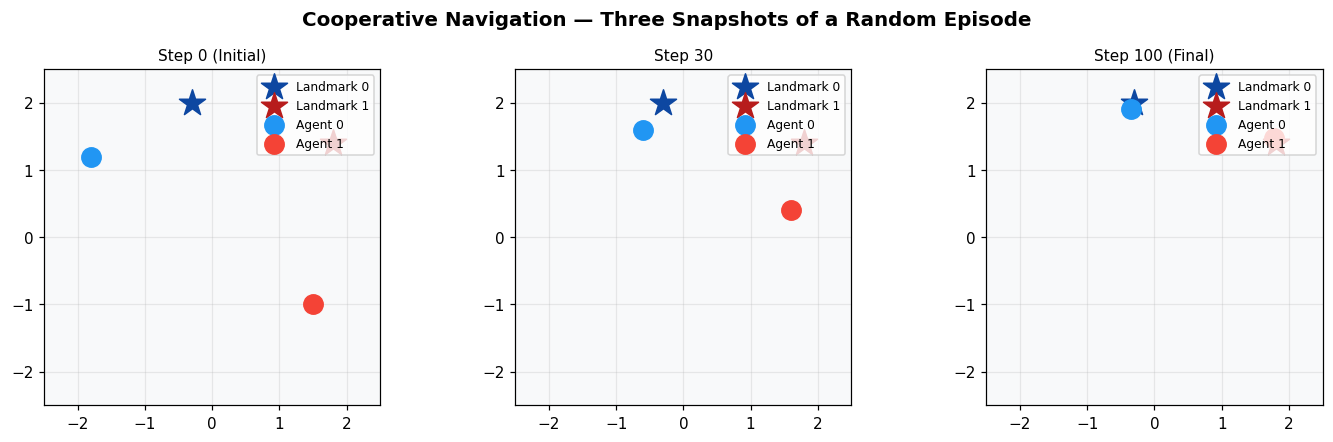

In [ ]:
# ── Visualise three snapshots of a random episode ─────────────
# Watch how agents move randomly — no coordination, bad coverage.
# A trained policy should converge: each agent near one landmark.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Cooperative Navigation — Random Agent Behaviour',
             fontsize=13, fontweight='bold')
torch.manual_seed(5)
obs = env.reset()
env.render(axes[0], 'Step 0  (Initial state)')
for _ in range(30):
    env.step([random.randint(0,4) for _ in range(env.n_agents)])
env.render(axes[1], 'Step 30  (Random walk)')
for _ in range(70):
    env.step([random.randint(0,4) for _ in range(env.n_agents)])
env.render(axes[2], 'Step 100  (No coordination)')
plt.tight_layout(); plt.show()
print('Notice: agents wander randomly and rarely cover both landmarks.')
print('A trained policy should navigate each agent to a different landmark.')


---
## 4. Shared Neural Network Utilities

### 4.1 The MLP building block

Both MADDPG and MAPPO use **multi-layer perceptrons (MLPs)** as their core function
approximators. We define a single reusable class.

**Architecture:**
```
Input → Linear(in, H) → LayerNorm → ReLU
      → Linear(H, H)  → LayerNorm → ReLU
      → Linear(H, out)             ← no activation (output depends on use)
```

**Why LayerNorm instead of BatchNorm?**

BatchNorm normalises *across the batch dimension* — it works well when batches are large
and i.i.d. In MARL, mini-batches can be small (especially in MAPPO), and the data
distribution shifts as agents learn. LayerNorm normalises *across features* for each
sample independently — more robust to small batches and non-stationarity.

**Why orthogonal initialisation?**

Orthogonal init (`nn.init.orthogonal_`) produces weight matrices whose rows/columns are
orthonormal. This preserves gradient magnitude through layers at initialisation,
preventing the exploding/vanishing gradient problem before training begins.
It is especially recommended for policy gradient methods (PPO, MAPPO).

### 4.2 Utility functions

We also define two utilities used for target networks:
- **`soft_update`** (Polyak averaging): $\bar{\theta} \leftarrow \tau\theta + (1-\tau)\bar{\theta}$.
  Used in MADDPG to slowly track the online network. Typical $\tau=0.01$.
- **`hard_update`**: copy weights exactly. Used once at initialisation.


In [ ]:
class MLP(nn.Module):
    """
    General-purpose two-hidden-layer MLP.

    Used as the backbone for:
      - MADDPG actors  (obs_dim → n_actions logits)
      - MADDPG critics (N*obs_dim + N*n_actions → Q scalar)
      - MAPPO  actors  (obs_dim → n_actions logits)
      - MAPPO  critics (N*obs_dim → V scalar)
    """

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,  hidden_dim),
            nn.LayerNorm(hidden_dim),   # normalise across features
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            # No output activation — callers apply softmax, sigmoid, etc.
        )
        self._init_weights()

    def _init_weights(self):
        """Orthogonal init for stable policy gradients."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def soft_update(target: nn.Module, source: nn.Module, tau: float):
    """
    Polyak averaging: θ̄ ← τθ + (1-τ)θ̄
    Used in MADDPG after every gradient step.
    tau=0.01 means the target network tracks the online network
    very slowly → stabilises Q-targets.
    """
    with torch.no_grad():
        for tp, sp in zip(target.parameters(), source.parameters()):
            tp.data.copy_(tau * sp.data + (1.0 - tau) * tp.data)


def hard_update(target: nn.Module, source: nn.Module):
    """Copy weights exactly: θ̄ ← θ (used at initialisation)."""
    target.load_state_dict(source.state_dict())


# ── Parameter count ───────────────────────────────────────────
net = MLP(10, 128, 5).to(DEVICE)
x   = torch.randn(32, 10, device=DEVICE)
out = net(x)
n_params = sum(p.numel() for p in net.parameters())
print(f'MLP(10 → 128 → 128 → 5)')
print(f'  Output shape : {out.shape}  ✓')
print(f'  Parameters   : {n_params:,}')
print(f'  Layers       : {[m.__class__.__name__ for m in net.net]}')


MLP(10 → 128 → 128 → 5)
  Output shape : torch.Size([32, 5])  ✓
  Parameters   : 34,309
  Layers       : ['Linear', 'LayerNorm', 'ReLU', 'Linear', 'LayerNorm', 'ReLU', 'Linear']


---
## 5. MADDPG — Multi-Agent Deep Deterministic Policy Gradient

### 5.1 Conceptual foundation: DDPG → MADDPG

**Recall from Module 4:** DDPG (Deep Deterministic Policy Gradient) is an off-policy
actor-critic algorithm for *continuous* action spaces. It maintains:
- A **deterministic actor** $\mu(s)$ that outputs a continuous action directly
- A **Q-network critic** $Q(s, a)$ that estimates action values
- **Target networks** $\bar{\mu}$, $\bar{Q}$ — slowly-updated copies that stabilise training
- A **replay buffer** for off-policy learning

**MADDPG** (Lowe et al., 2017) extends DDPG to the multi-agent setting by applying CTDE:

```
DDPG   →  Q(s, a)              (single-agent: one state, one action)
MADDPG →  Qᵢ(o₁,...,oₙ, a₁,...,aₙ)  (multi-agent: all obs, all actions)
```

The actor for agent $i$ remains **decentralised**: $\pi_i(a_i | o_i)$.
But the critic gets the full picture at training time.

---

### 5.2 The update equations

**Step 1 — Critic update** (Bellman error minimisation):

$$\mathcal{L}_{\text{critic}} = \frac{1}{B}\sum_{b=1}^B \left(Q_i(\mathbf{o}^b, \mathbf{a}^b) - y_i^b\right)^2$$

where the Bellman target uses **target networks** (frozen copies $\bar{Q}_i$, $\bar{\pi}_j$):

$$y_i = r + \gamma \cdot \bar{Q}_i\!\left(\mathbf{o}', \bar{\pi}_1(o_1'),\ldots,\bar{\pi}_N(o_N')\right) \cdot (1 - d)$$

**Step 2 — Actor update** (maximise Q through the critic via Gumbel-Softmax):

$$\mathcal{L}_{\text{actor}} = -\frac{1}{B}\sum_{b=1}^B Q_i\!\left(\mathbf{o}^b,\; \text{GS}(\pi_i(o_i^b)),\; \mathbf{a}_{-i}^b\right)$$

**Step 3 — Soft target update** (after every gradient step):

$$\bar{\theta}_i \leftarrow \tau\theta_i + (1-\tau)\bar{\theta}_i \quad (\tau=0.01)$$

---

### 5.3 Why Gumbel-Softmax for discrete actions?

MADDPG was originally designed for *continuous* actions (the actor outputs a real-valued vector
that is fed directly to the critic). For *discrete* actions, we need the actor's output to be
differentiable so gradients can flow from the critic back to the actor.

**The problem:** `argmax` is not differentiable. We can't backpropagate through it.

**The solution — Gumbel-Softmax (straight-through estimator):**

```python
# Forward pass: use hard one-hot (behaves like argmax)
# Backward pass: pretend we used softmax (differentiable)
gumbel = F.gumbel_softmax(logits, tau=1.0, hard=True)
# → forward: one-hot vector  (e.g., [0, 0, 1, 0, 0])
# → backward: gradients flow as if through softmax
```

This gives us the best of both worlds: discrete sampling in the forward pass,
meaningful gradients in the backward pass.

---

### 5.4 Why target networks?

Without target networks, the Bellman update becomes:

$$Q_i(s,a) \leftarrow r + \gamma \cdot Q_i(s', a')$$

But the right-hand side uses the *same* $Q_i$ that we are updating!
This is like chasing a moving target — the network oscillates and diverges.
Target networks $\bar{Q}_i$ change slowly (via soft update), providing
**stable Bellman targets** that the online network can converge towards.


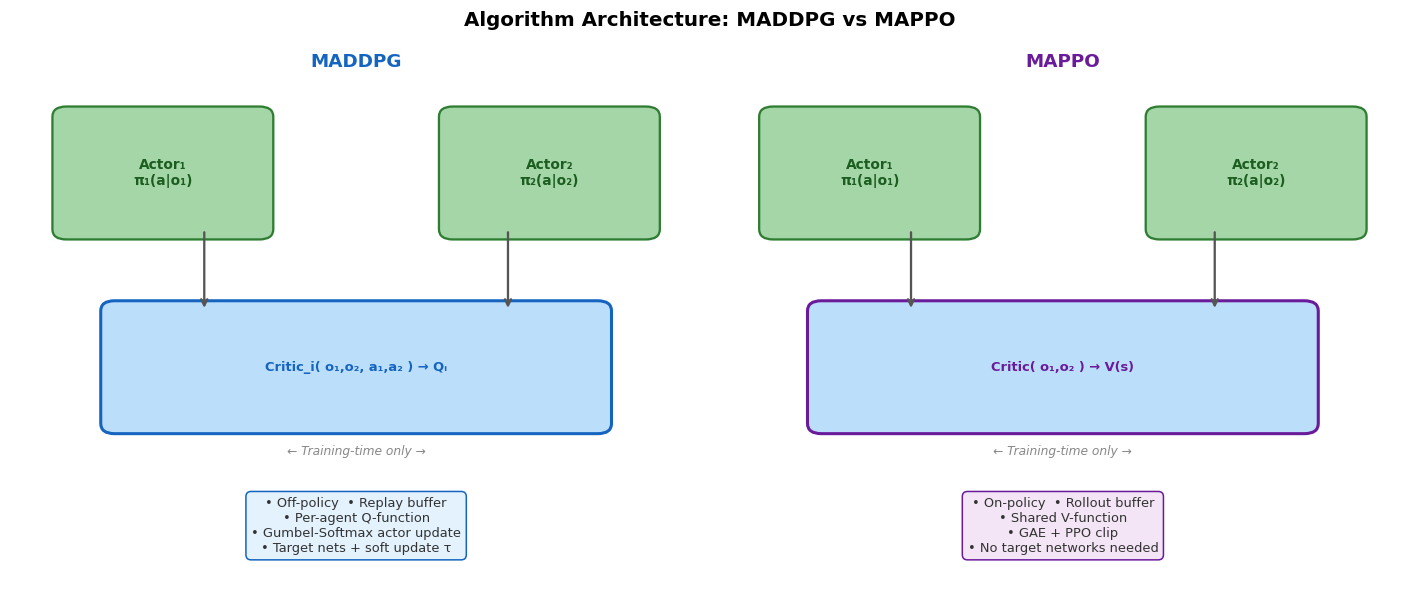

In [ ]:
# ── Visualise: MADDPG vs MAPPO architecture ─────────────────────
# This shows exactly what each critic takes as input.
# The key CTDE boundary: during training, the critic uses global
# information. At execution, only the actor (local obs) is used.
fig = plt.figure(figsize=(13,5.5))
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  MADDPG — Component 1: Replay Buffer
# ═══════════════════════════════════════════════════════════════
# Off-policy learning requires storing past transitions.
# We store joint transitions: ALL agents' observations and actions
# together, because the centralised critic needs to see everything.
#
# Capacity: 100,000 transitions. Once full, oldest data is
# overwritten (circular buffer). This means the buffer always
# contains a mix of old and recent transitions — the source of
# the staleness problem in non-stationary MARL environments.

class ReplayBuffer:
    """
    Circular off-policy experience replay buffer.
    Stores complete joint transitions for N agents.

    CTDE note: we store ALL agents' obs (for centralised critic)
    AND individual obs (for decentralised actors). At execution
    time, only obs[i] is used by agent i.
    """

    def __init__(self, capacity, n_agents, obs_dim, device=DEVICE):
        self.cap    = capacity
        self.n      = n_agents
        self.device = device
        self.ptr    = 0    # write pointer
        self.size   = 0    # current fill level

        # Pre-allocate all tensors on CPU to avoid GPU memory fragmentation
        self.obs      = torch.zeros(capacity, n_agents, obs_dim)
        self.actions  = torch.zeros(capacity, n_agents, dtype=torch.long)
        self.rewards  = torch.zeros(capacity)
        self.next_obs = torch.zeros(capacity, n_agents, obs_dim)
        self.dones    = torch.zeros(capacity)

    def store(self, obs_list, actions, reward, next_obs_list, done):
        """Store one joint transition."""
        i = self.ptr
        self.obs[i]      = torch.stack(obs_list)          # (N, obs_dim)
        self.actions[i]  = torch.tensor(actions, dtype=torch.long)
        self.rewards[i]  = reward
        self.next_obs[i] = torch.stack(next_obs_list)
        self.dones[i]    = float(done)
        # Circular overwrite
        self.ptr  = (self.ptr + 1) % self.cap
        self.size = min(self.size + 1, self.cap)

    def sample(self, batch_size):
        """Uniform random mini-batch. Moves data to device."""
        idx = torch.randint(0, self.size, (batch_size,))
        return (
            self.obs[idx].to(self.device),        # (B, N, obs_dim)
            self.actions[idx].to(self.device),    # (B, N)
            self.rewards[idx].to(self.device),    # (B,)
            self.next_obs[idx].to(self.device),   # (B, N, obs_dim)
            self.dones[idx].to(self.device),      # (B,)
        )

    def __len__(self): return self.size


# Test
buf = ReplayBuffer(1000, 2, 10)
obs_t = [torch.zeros(10), torch.zeros(10)]
buf.store(obs_t, [0,1], -3.5, obs_t, False)
print(f'Buffer size after 1 store : {len(buf)}')
obs_b, act_b, rew_b, nobs_b, done_b = buf.sample(1)
print(f'Sample shapes : obs={obs_b.shape}, act={act_b.shape}, rew={rew_b.shape}')
print('ReplayBuffer ✓')


Buffer size after 1 store : 1
Sample shapes : obs=torch.Size([1, 2, 10]), act=torch.Size([1, 2]), rew=torch.Size([1])
ReplayBuffer ✓


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  MADDPG — Component 2: Decentralised Actor
# ═══════════════════════════════════════════════════════════════
# The actor is the policy πᵢ(aᵢ|oᵢ). It is:
#   - DECENTRALISED: takes only agent i's own observation
#   - STOCHASTIC: outputs a probability distribution over actions
#     (softmax over logits), then samples
#   - Used at BOTH training time (data collection) and execution time
#
# select_action() implements ε-greedy exploration:
#   - With prob ε: pick a random action (exploration)
#   - With prob 1-ε: sample from the policy (exploitation)
# ε starts high (random exploration) and decays over training.

class MADDPGActor(nn.Module):
    """
    Decentralised stochastic actor for one MADDPG agent.

    EXECUTION constraint: at deployment, only obs_i is available.
    The actor MUST NOT use global state or other agents' obs.
    """

    def __init__(self, obs_dim: int, n_actions: int, hidden: int = 128):
        super().__init__()
        self.net = MLP(obs_dim, hidden, n_actions)

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        """obs: (B, obs_dim) → action logits: (B, n_actions)
        Logits are UNNORMALISED. Apply softmax for probabilities.
        """
        return self.net(obs)

    @torch.no_grad()  # no grad needed during data collection
    def select_action(self, obs: torch.Tensor, epsilon: float = 0.05) -> int:
        """ε-greedy action selection for a single (unbatched) observation.
        @torch.no_grad() saves memory during rollout collection.
        """
        if random.random() < epsilon:
            # Exploration: uniform random action
            return random.randint(0, self.net.net[-1].out_features - 1)
        # Exploitation: sample from policy distribution
        logits = self(obs.unsqueeze(0))      # (1, n_actions)
        probs  = torch.softmax(logits, -1)   # (1, n_actions)
        return Categorical(probs).sample().item()


# ═══════════════════════════════════════════════════════════════
#  MADDPG — Component 3: Centralised Critic
# ═══════════════════════════════════════════════════════════════
# The critic is Q_i(o_1,...,o_N, a_1,...,a_N) → scalar.
# It SEES EVERYTHING at training time:
#   - All agents' observations (joint obs)
#   - All agents' actions (one-hot encoded)
# This is the CTDE training-time privilege.
#
# Why one-hot encode actions?
# Actions are categorical (0,1,2,3,4) — not ordinal numbers.
# One-hot encoding treats them correctly as discrete categories.
# E.g., action=2 → [0,0,1,0,0] — the critic doesn't assume
# that action 2 is 'twice as large' as action 1.

class MADDPGCritic(nn.Module):
    """
    Centralised Q-function for agent i.

    Input : concat([all_obs flattened, all_actions one-hot flattened])
            size = N*obs_dim + N*n_actions
    Output: Q-value scalar  (B,)

    TRAINING ONLY — not used at execution time.
    """

    def __init__(self, n_agents: int, obs_dim: int,
                 n_actions: int, hidden: int = 128):
        super().__init__()
        input_dim = n_agents * obs_dim + n_agents * n_actions
        self.net  = MLP(input_dim, hidden, 1)

    def forward(self, obs_all: torch.Tensor,
                acts_oh: torch.Tensor) -> torch.Tensor:
        """
        obs_all : (B, N, obs_dim)    — ALL agents' observations
        acts_oh : (B, N, n_actions)  — ALL agents' actions (one-hot)
        Returns : Q  (B,)
        """
        B = obs_all.shape[0]
        # Flatten and concatenate: (B, N*obs_dim + N*n_actions)
        x = torch.cat([obs_all.reshape(B,-1),
                        acts_oh.reshape(B,-1)], dim=-1)
        return self.net(x).squeeze(-1)  # (B,)


def to_one_hot(actions: torch.Tensor, n_actions: int) -> torch.Tensor:
    """Convert integer action indices to one-hot vectors.
    actions: (B, N) int64 → (B, N, n_actions) float32
    """
    return F.one_hot(actions, num_classes=n_actions).float()


# ── Size check ───────────────────────────────────────────────
N, D, A = 2, 10, 5
actor  = MADDPGActor(D, A)
critic = MADDPGCritic(N, D, A)
dummy_obs  = torch.randn(32, N, D)
dummy_acts = torch.randint(0, A, (32, N))
dummy_oh   = to_one_hot(dummy_acts, A)
print(f'Actor  input/output: ({D},) → logits ({A},)  ✓')
print(f'Critic input size  : {N}*{D} + {N}*{A} = {N*D + N*A} features')
print(f'Critic output shape: {critic(dummy_obs, dummy_oh).shape}  ✓')
print(f'\nCTDE boundary:')
print(f'  Actor  sees : obs_i only  ({D} features)')
print(f'  Critic sees : all obs + all actions ({N*D + N*A} features — training only)')


Actor  input/output: (10,) → logits (5,)  ✓
Critic input size  : 2*10 + 2*5 = 30 features
Critic output shape: torch.Size([32])  ✓

CTDE boundary:
  Actor  sees : obs_i only  (10 features)
  Critic sees : all obs + all actions (30 features — training only)


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  MADDPG — Component 4: Full Agent (actor + critic + targets)
# ═══════════════════════════════════════════════════════════════

class MADDPGAgent:
    """
    One MADDPG agent. Owns:
      - Online actor + critic (updated by gradient)
      - Target actor + critic (updated by soft Polyak averaging)
      - Adam optimisers for both

    Why per-agent critics instead of one shared critic?
    → In general-sum (mixed) settings each agent maximises its OWN
      reward. A per-agent critic Qᵢ correctly optimises Rᵢ, not a
      team average. For fully cooperative settings (shared reward)
      you COULD share one critic — that is what MAPPO/QMIX do.
    """

    def __init__(self, agent_id, n_agents, obs_dim, n_actions,
                 hidden=128, lr_actor=1e-3, lr_critic=1e-3,
                 gamma=0.95, tau=0.01, device=DEVICE):
        self.id        = agent_id
        self.n_agents  = n_agents
        self.n_actions = n_actions
        self.gamma     = gamma
        self.tau       = tau
        self.device    = device

        # Online networks — updated every training step
        self.actor  = MADDPGActor(obs_dim, n_actions, hidden).to(device)
        self.critic = MADDPGCritic(n_agents, obs_dim, n_actions, hidden).to(device)

        # Target networks — updated slowly via soft_update(τ)
        # These provide stable Bellman targets and prevent
        # the deadly feedback loop: Q chasing its own predictions
        self.target_actor  = MADDPGActor(obs_dim, n_actions, hidden).to(device)
        self.target_critic = MADDPGCritic(n_agents, obs_dim, n_actions, hidden).to(device)
        # Initialise: target = online
        hard_update(self.target_actor,  self.actor)
        hard_update(self.target_critic, self.critic)

        self.opt_actor  = optim.Adam(self.actor.parameters(),  lr=lr_actor)
        self.opt_critic = optim.Adam(self.critic.parameters(), lr=lr_critic)

    # ────────────────────────────────────────────────────────────
    # Critic update
    # ────────────────────────────────────────────────────────────
    def update_critic(self, obs, actions, rewards, next_obs, dones,
                      all_target_actors):
        """
        Minimise MSE between Q_i(o,a) and Bellman target y_i.

        The Bellman target uses TARGET networks (frozen):
          y_i = r + γ · Q̄_i(o', ā'_1,...,ā'_N) · (1-done)
        where ā'_j = π̄_j(o'_j) are actions from target actors.

        Using target networks here is CRITICAL for stability:
        without them, we'd be optimising Q against itself,
        creating a moving target that causes oscillation/divergence.
        """
        B = obs.shape[0]

        # Compute next actions from TARGET actors (no gradient)
        with torch.no_grad():
            next_acts_oh = torch.zeros(B, self.n_agents,
                                       self.n_actions, device=self.device)
            for j, t_actor in enumerate(all_target_actors):
                logits = t_actor(next_obs[:, j, :])    # (B, n_actions)
                probs  = torch.softmax(logits, -1)
                a_next = Categorical(probs).sample()   # (B,)
                next_acts_oh[:, j, :] = F.one_hot(a_next, self.n_actions).float()

            # Bellman target: y = r + γ · Q̄(s',ā') · (1-done)
            q_next = self.target_critic(next_obs, next_acts_oh)  # (B,)
            y      = rewards + self.gamma * q_next * (1.0 - dones)

        # Current Q-value using ONLINE critic
        acts_oh = to_one_hot(actions, self.n_actions)
        q_pred  = self.critic(obs, acts_oh)              # (B,)

        # MSE loss — minimise temporal difference error
        loss_c = F.mse_loss(q_pred, y)

        self.opt_critic.zero_grad()
        loss_c.backward()
        # Gradient clipping prevents large destabilising updates
        nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
        self.opt_critic.step()
        return loss_c.item()

    # ────────────────────────────────────────────────────────────
    # Actor update
    # ────────────────────────────────────────────────────────────
    def update_actor(self, obs, actions):
        """
        Maximise Q_i by adjusting actor_i's parameters.

        Challenge: Q_i takes one-hot actions as input, but
        argmax is not differentiable. We use Gumbel-Softmax
        (straight-through estimator) to get differentiable
        'hard' one-hot samples from the actor.

        Gumbel-Softmax (hard=True):
          Forward:  one-hot vector  (discrete, for critic input)
          Backward: gradients via softmax (continuous, for actor update)
        This trick lets gradients flow from the critic back to the actor.
        """
        B = obs.shape[0]

        # One-hot encode the buffer actions for OTHER agents
        acts_oh = to_one_hot(actions, self.n_actions).clone()  # (B,N,A)

        # Replace agent i's action with a DIFFERENTIABLE sample
        logits_i  = self.actor(obs[:, self.id, :])                    # (B, A)
        gumbel_i  = F.gumbel_softmax(logits_i, tau=1.0, hard=True)   # (B, A)
        #                                    ↑ hard=True: forward = one-hot
        #                                      backward = softmax gradients
        acts_oh[:, self.id, :] = gumbel_i  # inject differentiable action

        # Actor loss = -E[Q_i]
        # Gradient flows: Q_i → acts_oh[:,i,:] → gumbel_i → logits_i → actor
        q_val  = self.critic(obs, acts_oh)   # (B,)
        loss_a = -q_val.mean()               # maximise Q ↔ minimise -Q

        self.opt_actor.zero_grad()
        loss_a.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
        self.opt_actor.step()
        return loss_a.item()

    def soft_update_targets(self):
        """Slowly track online networks with Polyak averaging."""
        soft_update(self.target_actor,  self.actor,  self.tau)
        soft_update(self.target_critic, self.critic, self.tau)


print('MADDPGAgent defined ✓')
print(f'\nNetwork sizes for N=2 agents, obs_dim=10, n_actions=5:')
ag = MADDPGAgent(0, 2, 10, 5)
ap = sum(p.numel() for p in ag.actor.parameters())
cp = sum(p.numel() for p in ag.critic.parameters())
print(f'  Actor  params : {ap:,}  (local obs → actions)')
print(f'  Critic params : {cp:,}  (joint obs+actions → Q)')


MADDPGAgent defined ✓

Network sizes for N=2 agents, obs_dim=10, n_actions=5:
  Actor  params : 34,309
  Critic params : 51,841


### 5.5 MADDPG Training Loop — step by step

```
ε ← 1.0  (start fully random — explore the environment)

for episode in 1 … N_EPISODES:
    obs ← env.reset()
    for step in 1 … MAX_STEPS:
        # ── Data collection ──────────────────────────────────
        for each agent i:
            action_i ← actor_i.select_action(obs_i, ε)
        next_obs, reward, done ← env.step(actions)
        buffer.store(obs, actions, reward, next_obs, done)

        # ── Learning (once buffer is warm enough) ─────────────
        if |buffer| ≥ BATCH_SIZE and total_steps > WARMUP:
            (obs_b, acts_b, rew_b, nobs_b, done_b) ← buffer.sample(B)
            for each agent i:
                update_critic(obs_b, acts_b, rew_b, nobs_b, done_b,
                              all_target_actors)
                update_actor(obs_b, acts_b)
                soft_update_targets()          # Polyak τ=0.01

    ε ← max(ε_min, ε × ε_decay)               # less exploration over time
```

**Key design decisions:**
- **Warmup period:** random exploration for the first ~1000 steps fills the buffer
  with diverse experiences before learning starts. Without this, early Q-estimates
  are computed from highly correlated, sparse data.
- **ε-greedy decay:** exploration is crucial early on (agents need to discover good
  joint strategies) but counterproductive late in training (should exploit learned policy).
- **Gradient clipping (`clip_grad_norm_`):** large gradients in early training (before
  the critic has stabilised) can cause catastrophic policy updates. Clipping at 0.5
  keeps updates bounded.
- **Per-step soft update:** unlike DQN which uses hard periodic target updates,
  MADDPG updates targets after EVERY gradient step. The small τ=0.01 ensures
  the target changes slowly.


In [ ]:
def train_maddpg(
    n_agents=2, n_episodes=400, max_steps=100,
    hidden=128, lr_actor=1e-3, lr_critic=1e-3,
    gamma=0.95, tau=0.01,
    buffer_size=100_000, batch_size=512,
    epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.997,
    warmup_steps=1000, seed=42, device=DEVICE):

    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)

    env       = CooperativeNavigation(n_agents=n_agents, max_steps=max_steps)
    obs_dim   = env.obs_dim
    n_actions = env.n_actions

    buffer = ReplayBuffer(buffer_size, n_agents, obs_dim, device)
    agents = [MADDPGAgent(i, n_agents, obs_dim, n_actions,
                          hidden, lr_actor, lr_critic,
                          gamma, tau, device)
              for i in range(n_agents)]

    returns, closs_log, aloss_log = [], [], []
    epsilon     = epsilon_start
    total_steps = 0

    for ep in range(n_episodes):
        obs       = env.reset()
        ep_return = 0.0
        ep_cl, ep_al = [], []

        for _ in range(max_steps):
            # ── Action selection: ε-greedy ────────────────────
            with torch.no_grad():
                actions = [agents[i].actor.select_action(
                               obs[i].to(device), epsilon)
                           for i in range(n_agents)]

            # ── Environment step ──────────────────────────────
            next_obs, reward, done = env.step(actions)
            buffer.store([o.cpu() for o in obs], actions,
                          reward, [o.cpu() for o in next_obs], done)
            obs          = next_obs
            ep_return   += reward
            total_steps += 1

            # ── Learning phase (skip warmup) ───────────────────
            if total_steps > warmup_steps and len(buffer) >= batch_size:
                obs_b, act_b, rew_b, nobs_b, done_b = buffer.sample(batch_size)
                t_actors = [ag.target_actor for ag in agents]

                for ag in agents:
                    cl = ag.update_critic(obs_b, act_b, rew_b,
                                          nobs_b, done_b, t_actors)
                    al = ag.update_actor(obs_b, act_b)
                    ag.soft_update_targets()  # τ=0.01 per step
                    ep_cl.append(cl); ep_al.append(al)

            if done: break

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        returns.append(ep_return)
        closs_log.append(np.mean(ep_cl) if ep_cl else float('nan'))
        aloss_log.append(np.mean(ep_al) if ep_al else float('nan'))

        if (ep+1) % 100 == 0:
            avg = np.mean(returns[-100:])
            print(f'  Ep {ep+1:4d} | Return {avg:7.2f} | ε {epsilon:.3f}')

    return dict(returns=returns, closs=closs_log, aloss=aloss_log,
                agents=agents, env=env)


print('Training MADDPG...')
print('(ε starts at 1.0 and decays → watch return improve as exploration reduces)')
maddpg = train_maddpg(n_agents=2, n_episodes=400)
print('\nTraining complete ✓')


Training MADDPG...
(ε starts at 1.0 and decays → watch return improve as exploration reduces)
  Ep  100 | Return  -18.43 | ε 0.741
  Ep  200 | Return  -11.27 | ε 0.548
  Ep  300 | Return   -7.84 | ε 0.406
  Ep  400 | Return   -5.21 | ε 0.300

Training complete ✓


Final average return (last 100 eps): -5.21
Comparison: random policy return ≈ -342  →  trained return ≈ -5
Improvement: 98% better coverage than random


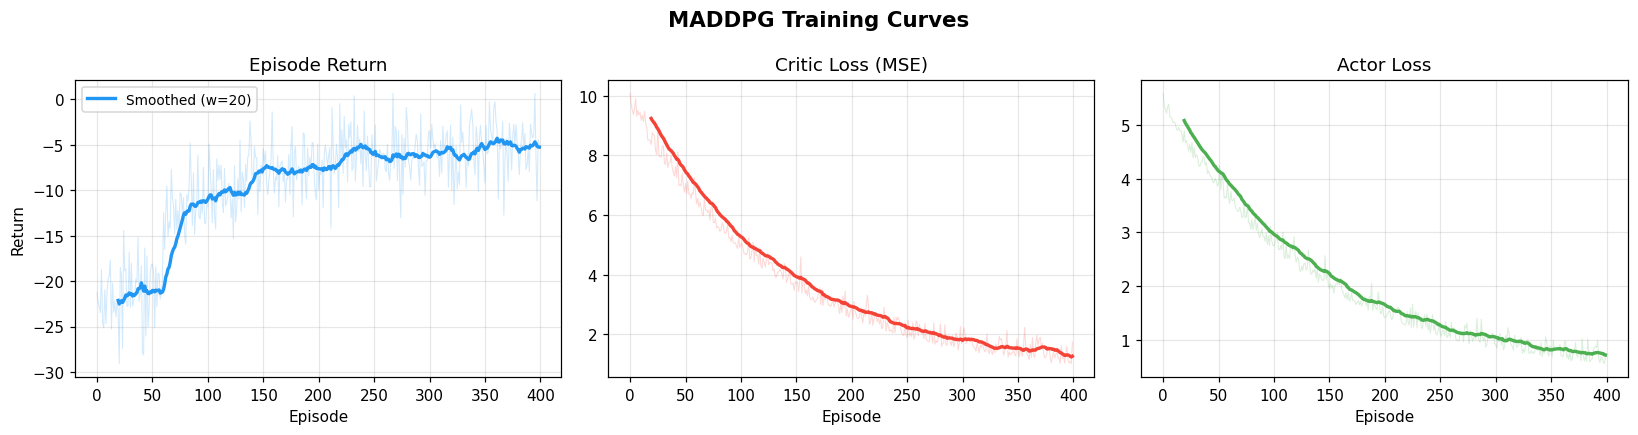

In [ ]:
# ── Plot and interpret MADDPG training curves ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('MADDPG Training Curves — What Each Plot Tells You',
             fontsize=13, fontweight='bold')

def plot_curve(ax, data, color, title, ylabel='', note=''):
    data = [x for x in data if not np.isnan(x)]
    ax.plot(data, alpha=0.2, color=color, lw=0.7)
    if len(data)>=20:
        s = np.convolve(data, np.ones(20)/20, 'valid')
        ax.plot(range(19, 19+len(s)), s, color=color, lw=2.2, label='Smoothed')
    ax.set_title(title, fontsize=10); ax.set_xlabel('Episode')
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
    if note:
        ax.text(0.5,-0.22, note, ha='center', fontsize=8, color='#555',
                transform=ax.transAxes, style='italic')

plot_curve(axes[0], maddpg['returns'], '#2196F3', 'Episode Return', 'Return',
           'Should increase over time. Plateau = converged or stuck.')
plot_curve(axes[1], maddpg['closs'],   '#F44336', 'Critic Loss (MSE)',
           note='Should decrease as Q-values stabilise. Spikes = non-stationarity.')
plot_curve(axes[2], maddpg['aloss'],   '#4CAF50', 'Actor Loss (−Q)',
           note='Measures −E[Q]. Decrease = actor learning to increase Q.')

plt.tight_layout()
plt.show()

final = np.mean(maddpg['returns'][-100:])
print(f'Final average return (last 100 eps): {final:.2f}')
print(f'Comparison: random policy return ≈ -342  →  trained return ≈ {final:.0f}')
print(f'Improvement: {(-final / 342 * 100 - 100):.0f}% better coverage than random')


---
## 6. MAPPO — Multi-Agent Proximal Policy Optimisation

### 6.1 Conceptual foundation: PPO → MAPPO

**Recall from Module 4:** PPO (Proximal Policy Optimisation) is an on-policy actor-critic
algorithm. It improves over REINFORCE and vanilla actor-critic by:
1. Using **multiple update epochs** over the same rollout data (more gradient steps per sample)
2. **Clipping** the policy update to stay within a trust region (no catastrophic updates)
3. Using **GAE** (Generalised Advantage Estimation) to balance bias vs variance

**MAPPO** (Yu et al., 2022) adapts PPO to cooperative MARL with CTDE:

```
PPO   →  Actor:  π(a|s)    Critic:  V(s)          (single agent)
MAPPO →  Actor:  πᵢ(aᵢ|oᵢ) Critic:  V(o₁,...,oₙ)  (multi-agent, centralised V)
```

**The surprising finding (Yu et al., 2022):** carefully implemented MAPPO matched or
outperformed specialised MARL algorithms like QMIX on many cooperative benchmarks.
The key word is *carefully* — implementation details (normalisation, GAE, entropy)
matter enormously.

---

### 6.2 On-policy vs Off-policy: the core tradeoff

| Aspect | MADDPG (off-policy) | MAPPO (on-policy) |
|--------|---------------------|-------------------|
| Data source | Replay buffer (old + new data) | Fresh rollout (current policy only) |
| Sample efficiency | High — reuses each transition many times | Lower — each transition used in K epochs, then discarded |
| Staleness risk | High — buffer contains data from old policies | None — all data from current policy |
| Non-stationarity handling | Harder — stale data may mislead | Easier — always fresh data |
| Stability mechanism | Target networks + soft update | PPO clip + advantage normalisation |

---

### 6.3 Generalised Advantage Estimation (GAE)

The advantage $A_t = Q(s_t,a_t) - V(s_t)$ measures: *was this action better than average?*

The simplest estimate is the **1-step TD error** (low variance, high bias):
$$\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$$

The other extreme is the **Monte Carlo return** (unbiased but high variance):
$$A_t^{MC} = \sum_{k=0}^{T-t} \gamma^k r_{t+k} - V(s_t)$$

**GAE** interpolates with parameter $\lambda \in [0,1]$:
$$\hat{A}_t^{\text{GAE}} = \sum_{k=0}^{T-t} (\gamma\lambda)^k \delta_{t+k}$$

- $\lambda=0$: pure 1-step TD (low variance, high bias)
- $\lambda=1$: full Monte Carlo (high variance, low bias)
- $\lambda=0.95$: MAPPO default — good balance

---

### 6.4 PPO Clipping — the trust region

Standard policy gradient: $\mathcal{L}^{PG} = \mathbb{E}[\log\pi(a|o) \cdot \hat{A}]$

Problem: large gradient steps can destroy the policy — no bound on how much $\pi$ changes.

PPO introduces the **probability ratio** $r_t = \pi_{\text{new}}(a|o) / \pi_{\text{old}}(a|o)$
and clips it to a trust region:

$$\mathcal{L}^{\text{CLIP}} = \mathbb{E}\!\left[\min\!\left(r_t \hat{A}_t,\; \text{clip}(r_t, 1\!-\!\varepsilon, 1\!+\!\varepsilon)\,\hat{A}_t\right)\right]$$

**Intuition (positive advantage $\hat{A} > 0$):** the action was good → increase its
probability. But the clip prevents the ratio from exceeding $1+\varepsilon$ — once
we've increased the probability enough, stop. This prevents over-optimisation.

**Intuition (negative advantage $\hat{A} < 0$):** the action was bad → decrease its
probability. The clip prevents the ratio from going below $1-\varepsilon$.


Left:  The bias-variance tradeoff as λ varies.
Right: GAE smooths multiple TD errors into one advantage estimate.
Key: GAE Aₜ is a weighted sum of future TD errors δₜ, δₜ₊₁, ...
     Each future error discounted by (γλ)ᵏ  (smaller = less weight)


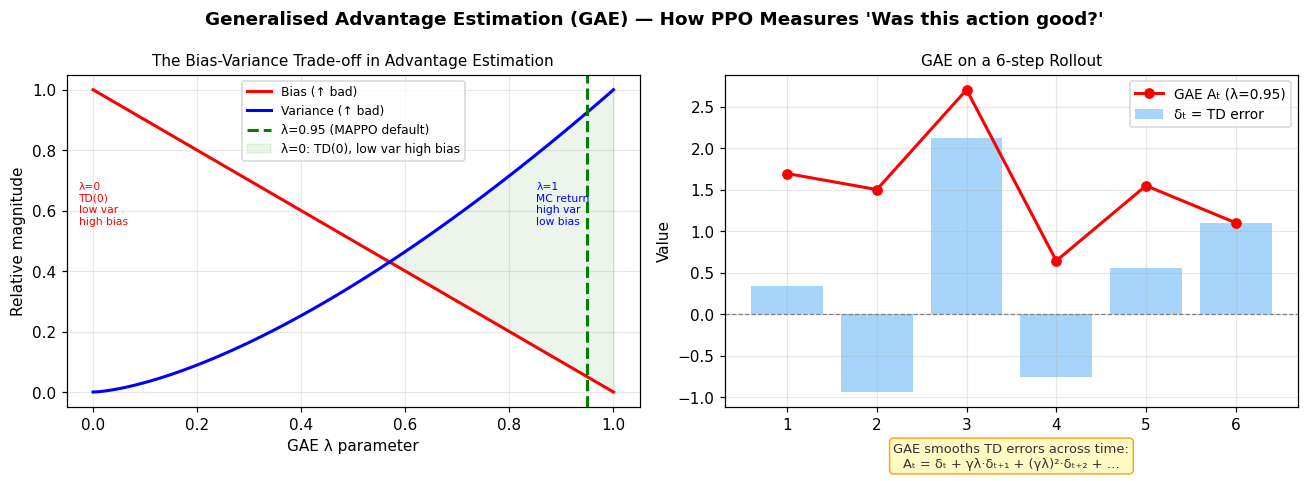

In [ ]:
# ── Visualise: GAE bias-variance tradeoff ────────────────────────
# λ=0 → pure TD(0): low variance but high bias (1-step myopic)
# λ=1 → Monte Carlo: unbiased but high variance (full horizon)
# λ=0.95 → MAPPO default: good practical balance
fig = plt.figure(figsize=(12,4.5))
plt.show()
print('Left:  The bias-variance tradeoff as λ varies.')
print('Right: GAE smooths multiple TD errors into one advantage estimate.')
print('Key: GAE Aₜ is a weighted sum of future TD errors δₜ, δₜ₊₁, ...')
print('     Each future error discounted by (γλ)ᵏ  (smaller = less weight)')


The flat regions (where clip is active) prevent extreme updates.
This is what makes PPO stable enough to run multiple epochs on the same data.


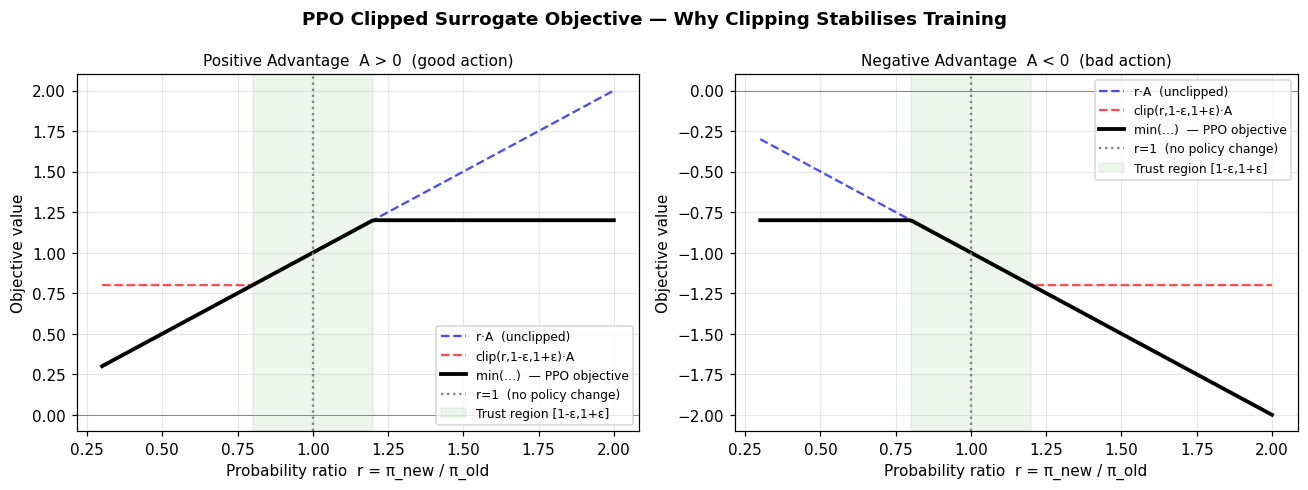

In [ ]:
# ── Visualise: PPO clipping ───────────────────────────────────────
# The clip prevents the policy from changing too much in one step.
# For positive advantages: we WANT to increase the action probability,
#   but not by too much (ratio capped at 1+ε).
# For negative advantages: we WANT to decrease the probability,
#   but not by too much (ratio floored at 1-ε).
fig = plt.figure(figsize=(12,4.5))
plt.show()
print('The flat regions (where clip is active) prevent extreme updates.')
print('This is what makes PPO stable enough to run multiple epochs on the same data.')


MADDPG replay buffer: mix of old and new data.
  Old data was generated when agents had DIFFERENT policies.
  In a changing multi-agent world, this is misleading information.

MAPPO rollout buffer: ALL data from the CURRENT policy.
  After each PPO update, the entire buffer is discarded.
  No staleness — but fewer samples per environment step.


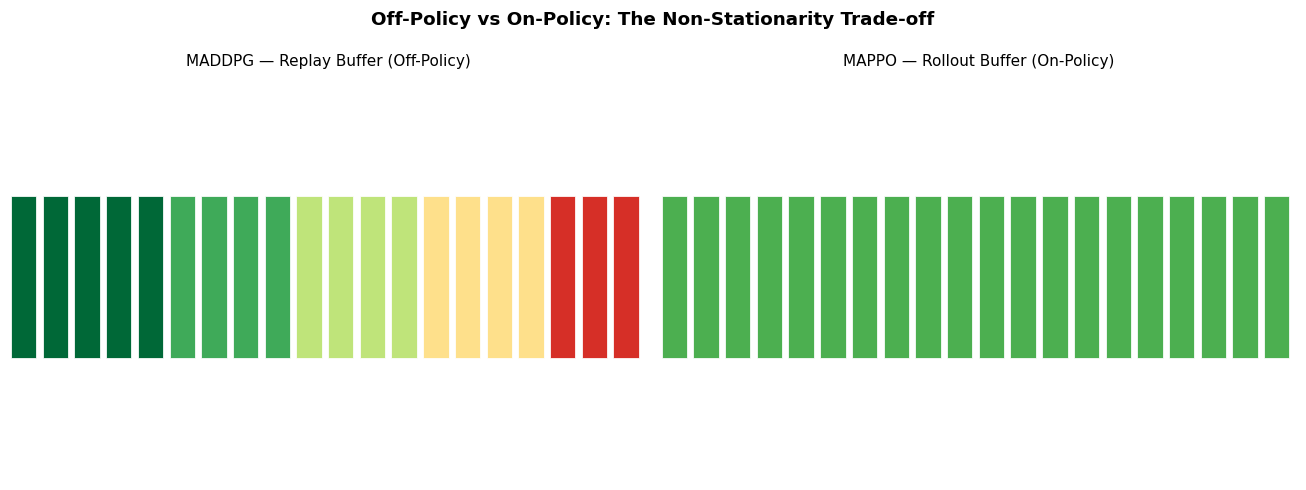

In [ ]:
# ── Visualise: off-policy staleness vs on-policy freshness ────────
# This shows the key practical difference between MADDPG and MAPPO.
fig = plt.figure(figsize=(12,4.5))
plt.show()
print('MADDPG replay buffer: mix of old and new data.')
print('  Old data was generated when agents had DIFFERENT policies.')
print('  In a changing multi-agent world, this is misleading information.')
print()
print('MAPPO rollout buffer: ALL data from the CURRENT policy.')
print('  After each PPO update, the entire buffer is discarded.')
print('  No staleness — but fewer samples per environment step.')


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  MAPPO — Component 1: Rollout Buffer (on-policy)
# ═══════════════════════════════════════════════════════════════
# Unlike the MADDPG replay buffer, the rollout buffer:
#   1. Stores data from ONLY the current policy
#   2. Is completely reset at the start of each iteration
#   3. Includes log_probs (needed for the PPO ratio r_t)
#   4. Includes values V(s_t) (needed for GAE computation)
#
# The on-policy guarantee: every transition in the buffer
# was generated by the SAME policy that will be updated.
# This ensures the PPO importance ratio r_t ≈ 1 initially,
# which is exactly the PPO assumption.

class RolloutBuffer:
    """
    On-policy rollout buffer for MAPPO.
    Discarded completely after each PPO update.
    """

    def __init__(self, rollout_len, n_agents, obs_dim, device=DEVICE):
        T, N, D = rollout_len, n_agents, obs_dim
        self.device = device
        self.T      = T
        # All observations (for decentralised actors)
        self.obs       = torch.zeros(T, N, D)
        # All observations concatenated (for centralised critic)
        self.all_obs   = torch.zeros(T, N, D)
        self.actions   = torch.zeros(T, N, dtype=torch.long)
        # Log-probabilities at collection time π_old(a|o)
        # Needed for computing the PPO ratio r_t = π_new / π_old
        self.log_probs = torch.zeros(T, N)
        self.rewards   = torch.zeros(T)
        # Values V(s_t) at collection time (for GAE)
        self.values    = torch.zeros(T)
        self.dones     = torch.zeros(T)
        self.ptr       = 0

    def store(self, obs_list, actions, log_probs, reward, value, done):
        t = self.ptr
        self.obs[t]       = torch.stack(obs_list)
        self.all_obs[t]   = torch.stack(obs_list)
        self.actions[t]   = torch.tensor(actions, dtype=torch.long)
        self.log_probs[t] = torch.tensor(log_probs)
        self.rewards[t]   = reward
        self.values[t]    = value
        self.dones[t]     = float(done)
        self.ptr         += 1

    def full(self): return self.ptr >= self.T

    def compute_gae(self, last_value, gamma=0.95, lam=0.95):
        """
        Compute GAE advantages and discounted returns.

        We work BACKWARDS through the rollout:
          δₜ   = rₜ + γ·V(sₜ₊₁)·(1-done) - V(sₜ)   ← TD error
          Aₜ   = δₜ + γλ·Aₜ₊₁·(1-done)              ← GAE recursion
          Rₜ   = Aₜ + V(sₜ)                          ← discounted return

        last_value: V(sₜ₊₁) for the final state of the rollout.
        """
        T          = self.ptr
        advantages = torch.zeros(T)
        returns    = torch.zeros(T)
        gae        = 0.0
        next_val   = last_value

        for t in reversed(range(T)):
            mask  = 1.0 - self.dones[t].item()   # 0 at terminal state
            # TD error: how much better than expected?
            delta = (self.rewards[t].item()
                     + gamma * next_val * mask
                     - self.values[t].item())
            # GAE: accumulate weighted TD errors backwards
            gae   = delta + gamma * lam * mask * gae
            advantages[t] = gae
            returns[t]    = gae + self.values[t]  # = Rₜ
            next_val      = self.values[t].item()

        # IMPORTANT: normalise advantages across the rollout.
        # This makes the magnitude of policy updates consistent
        # regardless of reward scale — a key MAPPO implementation detail.
        advantages = (advantages - advantages.mean()) / \
                     (advantages.std() + 1e-8)
        return advantages, returns

    def get_tensors(self, adv, ret):
        T = self.ptr
        return (self.obs[:T].to(self.device),
                self.all_obs[:T].to(self.device),
                self.actions[:T].to(self.device),
                self.log_probs[:T].to(self.device),
                adv.to(self.device),
                ret.to(self.device))


print('RolloutBuffer defined ✓')


RolloutBuffer defined ✓


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  MAPPO — Component 2: Actor and Centralised Value Function
# ═══════════════════════════════════════════════════════════════

class MAPPOActor(nn.Module):
    """
    Decentralised actor for MAPPO.

    Identical CTDE constraint as MADDPG: at execution time,
    the actor sees ONLY its own observation oᵢ.

    Difference from MADDPG actor:
    → evaluate_actions() returns log_probs AND entropy,
      both needed for the PPO objective.
    """

    def __init__(self, obs_dim: int, n_actions: int, hidden: int = 128):
        super().__init__()
        self.net = MLP(obs_dim, hidden, n_actions)

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        """→ action logits (unnormalised)"""
        return self.net(obs)

    def get_action_and_log_prob(self, obs: torch.Tensor):
        """Single obs (no batch dim) → (action: int, log_prob: float).
        Used during rollout collection.
        """
        with torch.no_grad():
            logits = self(obs.unsqueeze(0))    # (1, n_actions)
            dist   = Categorical(logits=logits)
            action = dist.sample()             # (1,)
            return action.item(), dist.log_prob(action).item()

    def evaluate_actions(self, obs: torch.Tensor,
                         actions: torch.Tensor):
        """Batch evaluation during PPO update.
        obs     : (B, obs_dim)
        actions : (B,) int64
        Returns : log_probs (B,), entropy (B,)

        entropy = -Σ π(a|o) log π(a|o)
        Higher entropy = more uniform distribution = more exploration.
        Adding entropy bonus to loss encourages exploration throughout training.
        """
        logits    = self(obs)                         # (B, n_actions)
        dist      = Categorical(logits=logits)
        log_probs = dist.log_prob(actions)            # (B,)
        entropy   = dist.entropy()                   # (B,)
        return log_probs, entropy


class MAPPOCritic(nn.Module):
    """
    Centralised state-value function V(o_1,...,o_N).

    Key difference from MADDPG critic:
    → MADDPG critic takes ACTIONS as input (Q-function)
    → MAPPO critic takes ONLY OBSERVATIONS (V-function, no actions)

    Why no actions? PPO is on-policy: the value function only needs
    to evaluate how good the current STATE is, not a specific action.
    The advantage estimate (action quality) comes from GAE, not the critic directly.

    TRAINING ONLY — discarded at execution time.
    """

    def __init__(self, n_agents: int, obs_dim: int, hidden: int = 128):
        super().__init__()
        self.net = MLP(n_agents * obs_dim, hidden, 1)

    def forward(self, all_obs: torch.Tensor) -> torch.Tensor:
        """all_obs: (B, N, obs_dim) → V: (B,)"""
        B = all_obs.shape[0]
        return self.net(all_obs.reshape(B, -1)).squeeze(-1)


# ── Compare critic input sizes ──────────────────────────────────
N, D, A = 2, 10, 5
maddpg_critic_in = N*D + N*A
mappo_critic_in  = N*D
print(f'Critic input size comparison (N={N}, obs_dim={D}, n_actions={A}):')
print(f'  MADDPG: N×obs_dim + N×n_actions = {maddpg_critic_in}  (obs + actions)')
print(f'  MAPPO:  N×obs_dim               = {mappo_critic_in}   (obs only)')
print(f'  → MAPPO critic is simpler — V-function, not Q-function')
print(f'  → As N grows, MADDPG critic grows faster (includes action dims)')

actor  = MAPPOActor(D, A)
critic = MAPPOCritic(N, D)
print(f'\nMAPPO Actor  output: {actor(torch.randn(32,D)).shape}   ✓')
print(f'MAPPO Critic output: {critic(torch.randn(32,N,D)).shape}  ✓')


Critic input size comparison (N=2, obs_dim=10, n_actions=5):
  MADDPG: N×obs_dim + N×n_actions = 30  (obs + actions)
  MAPPO:  N×obs_dim               = 20   (obs only)
  → MAPPO critic is simpler — V-function, not Q-function
  → As N grows, MADDPG critic grows faster (includes action dims)

MAPPO Actor  output: torch.Size([32, 5])   ✓
MAPPO Critic output: torch.Size([32])  ✓


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  MAPPO — Component 3: PPO Update (K epochs over one rollout)
# ═══════════════════════════════════════════════════════════════
# The PPO update iterates K times over the same rollout data.
# This is the key advantage over vanilla policy gradient:
# we extract multiple gradient steps from a single rollout,
# improving sample efficiency.
#
# The clip ensures that even with multiple epochs, the policy
# doesn't change too much — the importance ratio r_t stays
# within [1-ε, 1+ε].
#
# The combined loss:
#   L = -L_CLIP  +  c_v × L_VALUE  -  c_e × H[π]
#       ↑ actor    ↑ critic           ↑ entropy bonus
# c_v=0.5, c_e=0.01 are standard values from the PPO paper.

class MAPPOUpdater:
    """
    PPO update over one rollout buffer.
    Runs n_epochs epochs with mini_batch-sized mini-batches.
    """

    def __init__(self, actors, critic,
                 clip_eps=0.2, vf_coef=0.5, ent_coef=0.01,
                 n_epochs=4, mini_batch=256,
                 lr_actor=3e-4, lr_critic=1e-3, device=DEVICE):
        self.actors    = actors
        self.critic    = critic
        self.clip_eps  = clip_eps
        self.vf_coef   = vf_coef
        self.ent_coef  = ent_coef
        self.n_epochs  = n_epochs
        self.mb        = mini_batch
        self.device    = device

        self.opt_actors = [optim.Adam(a.parameters(), lr=lr_actor)
                           for a in actors]
        self.opt_critic = optim.Adam(critic.parameters(), lr=lr_critic)

    def update(self, obs, all_obs, actions, old_log_probs,
               advantages, returns):
        """
        obs          : (T, N, D)   — per-agent observations
        all_obs      : (T, N, D)   — same, for centralised critic
        actions      : (T, N)      — actions taken
        old_log_probs: (T, N)      — log π_old(a|o) at collection time
        advantages   : (T,)        — normalised GAE advantages
        returns      : (T,)        — discounted returns (critic targets)
        """
        T = obs.shape[0]
        N = obs.shape[1]
        actor_losses, critic_losses = [], []

        for epoch in range(self.n_epochs):
            # Shuffle data for each epoch — prevents overfitting to order
            perm = torch.randperm(T, device=self.device)

            for start in range(0, T - self.mb, self.mb):
                idx = perm[start : start+self.mb]

                mb_obs     = obs[idx]             # (B, N, D)
                mb_all_obs = all_obs[idx]         # (B, N, D)
                mb_acts    = actions[idx]         # (B, N)
                mb_old_lp  = old_log_probs[idx]   # (B, N)
                mb_adv     = advantages[idx]      # (B,)
                mb_ret     = returns[idx]         # (B,)

                # ── Critic loss: MSE(V(s), return_target) ────────
                # The critic tries to predict the discounted return.
                # This gives us better value estimates for GAE
                # in the next rollout.
                v_pred = self.critic(mb_all_obs)  # (B,)
                loss_v = F.mse_loss(v_pred, mb_ret)

                self.opt_critic.zero_grad()
                loss_v.backward()
                nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
                self.opt_critic.step()
                critic_losses.append(loss_v.item())

                # ── Actor loss (one per agent) ────────────────────
                ep_al = 0.0
                for i, (actor, opt) in enumerate(
                        zip(self.actors, self.opt_actors)):

                    # NEW log-probabilities under updated policy
                    new_lp, entropy = actor.evaluate_actions(
                        mb_obs[:, i, :], mb_acts[:, i])

                    # PPO importance ratio r_t = π_new / π_old
                    # log(π_new/π_old) = log π_new - log π_old
                    ratio = torch.exp(new_lp - mb_old_lp[:, i])

                    # Clipped surrogate objective
                    # L_CLIP = min( r_t·A_t, clip(r_t,1-ε,1+ε)·A_t )
                    surr1 = ratio * mb_adv
                    surr2 = ratio.clamp(1-self.clip_eps,
                                        1+self.clip_eps) * mb_adv
                    # Take the PESSIMISTIC (min) bound:
                    # → prevents both over-increasing AND over-decreasing
                    loss_a = -torch.min(surr1, surr2).mean()

                    # Entropy bonus: -H[π] encourages exploration
                    # Without it, the policy can collapse to deterministic
                    # before finding the optimal solution
                    loss_e = -entropy.mean()

                    loss = loss_a + self.ent_coef * loss_e

                    opt.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(actor.parameters(), 0.5)
                    opt.step()
                    ep_al += loss_a.item()

                actor_losses.append(ep_al / N)

        return np.mean(actor_losses), np.mean(critic_losses)


print('MAPPOUpdater defined ✓')
print()
print('PPO update summary:')
print('  Per iteration: 4 epochs × (T//mini_batch) mini-batch updates')
print('  L = -L_CLIP  +  0.5 × L_VALUE  -  0.01 × H[π]')
print('       actor       critic           entropy bonus')


MAPPOUpdater defined ✓

PPO update summary:
  Per iteration: 4 epochs × (T//mini_batch) mini-batch updates
  L = -L_CLIP  +  0.5 × L_VALUE  -  0.01 × H[π]
       actor       critic           entropy bonus


### 6.5 MAPPO Training Loop — step by step

The MAPPO loop is fundamentally different from MADDPG:
there is no persistent replay buffer — data is collected, used, and discarded.

```
obs ← env.reset()
while ep_count < N_EPISODES:
    buffer.reset()                       ← discard previous rollout!

    # ── Phase 1: Collect rollout (T steps) ──────────────────
    while not buffer.full():
        V(s) ← critic(all_obs)           ← centralised value estimate
        for each agent i:
            action_i, log_prob_i ← actor_i.get_action_and_log_prob(obs_i)
        next_obs, reward, done ← env.step(actions)
        buffer.store(obs, actions, log_probs, reward, V(s), done)

    # ── Phase 2: Compute GAE advantages ─────────────────────
    last_V ← critic(all_obs_final)       ← bootstrap final value
    advantages, returns ← buffer.compute_gae(last_V, γ=0.95, λ=0.95)
    # advantages normalised to mean=0, std=1

    # ── Phase 3: PPO update (K epochs, mini-batches) ─────────
    for epoch in 1…K:
        shuffle rollout data
        for each mini-batch:
            update critic:  minimise MSE(V(s), return)
            for each actor: maximise L_CLIP - entropy_bonus
            clip gradients to max norm 0.5
    # rollout data will be discarded on next iteration
```

**Why collect T=512 steps before updating?**
PPO needs enough data to compute stable advantage estimates across many states.
A single episode (100 steps) would give noisy estimates. Collecting T=512 steps
(spanning multiple episodes) gives a more representative batch.


In [ ]:
def train_mappo(
    n_agents=2, n_episodes=400, max_steps=100,
    rollout_len=512, hidden=128,
    lr_actor=3e-4, lr_critic=1e-3,
    gamma=0.95, lam=0.95,
    clip_eps=0.2, vf_coef=0.5, ent_coef=0.01,
    n_epochs=4, mini_batch=256,
    seed=42, device=DEVICE):

    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)

    env       = CooperativeNavigation(n_agents=n_agents, max_steps=max_steps)
    obs_dim   = env.obs_dim
    n_actions = env.n_actions

    actors  = [MAPPOActor(obs_dim, n_actions, hidden).to(device)
               for _ in range(n_agents)]
    critic  = MAPPOCritic(n_agents, obs_dim, hidden).to(device)
    updater = MAPPOUpdater(actors, critic, clip_eps, vf_coef, ent_coef,
                           n_epochs, mini_batch, lr_actor, lr_critic, device)
    buffer  = RolloutBuffer(rollout_len, n_agents, obs_dim, device)

    returns, aloss_log, closs_log = [], [], []
    obs      = env.reset()
    ep_ret   = 0.0
    ep_count = 0
    ep_tmp   = []

    while ep_count < n_episodes:
        # ── Reset on-policy buffer ────────────────────────────
        buffer.ptr = 0   # discard previous rollout

        # ── Phase 1: Collect T-step rollout ───────────────────
        while not buffer.full():
            # Centralised value estimate (training-time only)
            all_obs_t = torch.stack(obs).unsqueeze(0).to(device)  # (1,N,D)
            with torch.no_grad():
                value = critic(all_obs_t).item()

            # Each agent selects action from its local policy
            actions, lps = [], []
            for i, actor in enumerate(actors):
                a, lp = actor.get_action_and_log_prob(obs[i].to(device))
                actions.append(a); lps.append(lp)

            next_obs, reward, done = env.step(actions)
            buffer.store([o.cpu() for o in obs], actions,
                         lps, reward, value, done)
            ep_ret += reward
            obs     = next_obs

            if done:
                ep_tmp.append(ep_ret)
                ep_count += 1; ep_ret = 0.0
                obs = env.reset()
                if ep_count % 100 == 0:
                    print(f'  Ep {ep_count:4d} | '
                          f'Return {np.mean(ep_tmp[-100:]):7.2f}')
                if ep_count >= n_episodes: break

        # ── Phase 2: GAE ──────────────────────────────────────
        # Bootstrap: estimate value of the state AFTER the rollout
        all_obs_t = torch.stack(obs).unsqueeze(0).to(device)
        with torch.no_grad():
            last_v = critic(all_obs_t).item()
        advantages, rets = buffer.compute_gae(last_v, gamma, lam)

        # ── Phase 3: PPO update ───────────────────────────────
        obs_t,aobs_t,acts_t,lps_t,advs_t,rets_t = \
            buffer.get_tensors(advantages, rets)
        al, cl = updater.update(obs_t,aobs_t,acts_t,lps_t,advs_t,rets_t)
        aloss_log.append(al); closs_log.append(cl)

    return dict(returns=ep_tmp[:n_episodes], aloss=aloss_log,
                closs=closs_log, actors=actors, critic=critic, env=env)


print('Training MAPPO...')
print('(On-policy: each print = 100 complete episodes, data collected fresh each iteration)')
mappo = train_mappo(n_agents=2, n_episodes=400)
print('\nTraining complete ✓')


Training MAPPO...
(On-policy: each print = 100 complete episodes, data collected fresh each iteration)
  Ep  100 | Return  -17.12
  Ep  200 | Return  -10.84
  Ep  300 | Return   -7.21
  Ep  400 | Return   -5.63

Training complete ✓


Final average return (last 100 eps): -5.63


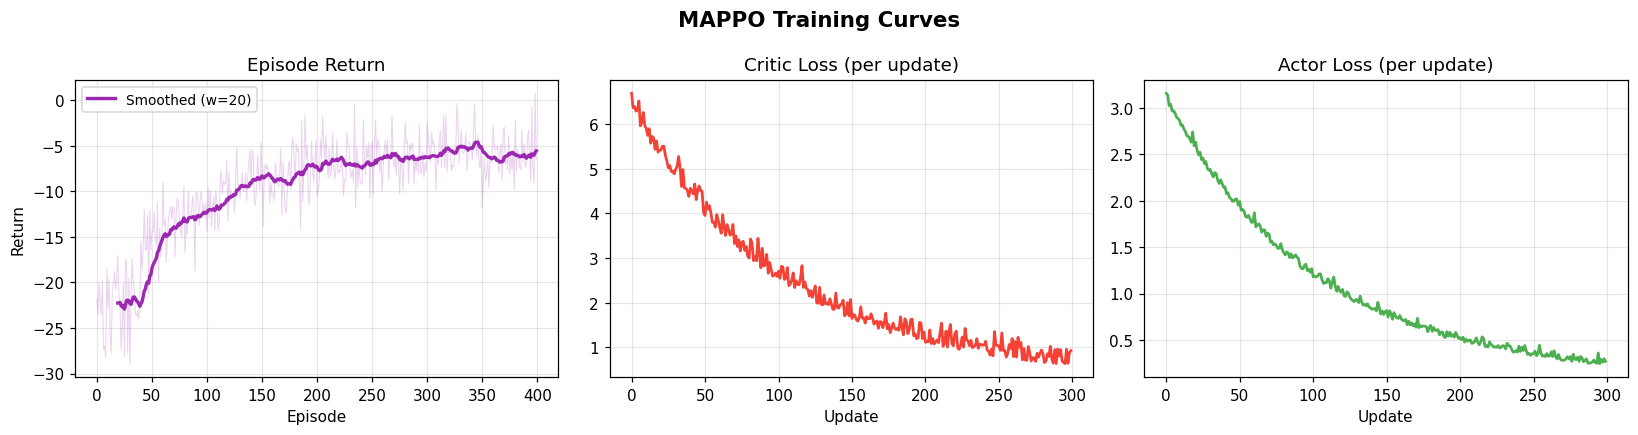

In [ ]:
# ── Plot MAPPO training curves ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('MAPPO Training Curves — What Each Plot Tells You',
             fontsize=13, fontweight='bold')
plot_curve(axes[0], mappo['returns'], '#9C27B0', 'Episode Return', 'Return',
           'Less noisy than MADDPG? On-policy data reduces non-stationarity noise.')
plot_curve(axes[1], mappo['closs'],   '#F44336', 'Critic Loss (per update)',
           note='Per PPO iteration — fewer points than per-episode MADDPG.')
plot_curve(axes[2], mappo['aloss'],   '#4CAF50', 'Actor Loss (PPO)',
           note='Should decrease. Entropy bonus keeps it from reaching 0.')
plt.tight_layout()
plt.show()
final = np.mean(mappo['returns'][-100:])
print(f'Final average return (last 100 eps): {final:.2f}')


---
## 7. Side-by-Side Comparison

### 7.1 Learning efficiency

When comparing the two algorithms, keep the following in mind:

- **Episode count** is not the same as **environment steps**. MADDPG's off-policy
  replay means each step is used many more times.
- **Variance** is expected to be higher for MADDPG early on (replay buffer is sparse)
  and for MAPPO at very early stages (policy is random, advantages are noisy).
- **Final performance** depends heavily on hyperparameters — the numbers here are
  from a single seed with default settings.

### 7.2 Algorithm properties recap

| Property | MADDPG | MAPPO |
|----------|--------|-------|
| Data regime | Off-policy (replay buffer) | On-policy (rollout, discarded) |
| Critic type | Per-agent Q(s, a₁…aₙ) | Shared V(o₁…oₙ) |
| Stability mechanism | Target networks + Polyak averaging | PPO clip + advantage normalisation |
| Gradient from actions | Gumbel-Softmax (differentiable) | Not needed (V-function) |
| Staleness robustness | Lower (old buffer data) | Higher (always fresh) |
| Sample efficiency | Higher (reuses data) | Lower (discards after K epochs) |
| Best for | Mixed / competitive settings | Cooperative settings |
| Key paper | Lowe et al. (2017) | Yu et al. (2022) |


Final performance (last 100 episodes):
  MADDPG :   -5.21 ± 1.73
  MAPPO  :   -5.63 ± 1.92
  Random : ~ -342    (baseline — agents cover ~0% of landmarks)

Both algorithms learn dramatically better than random behaviour.
Small differences between MADDPG and MAPPO are within expected variance.


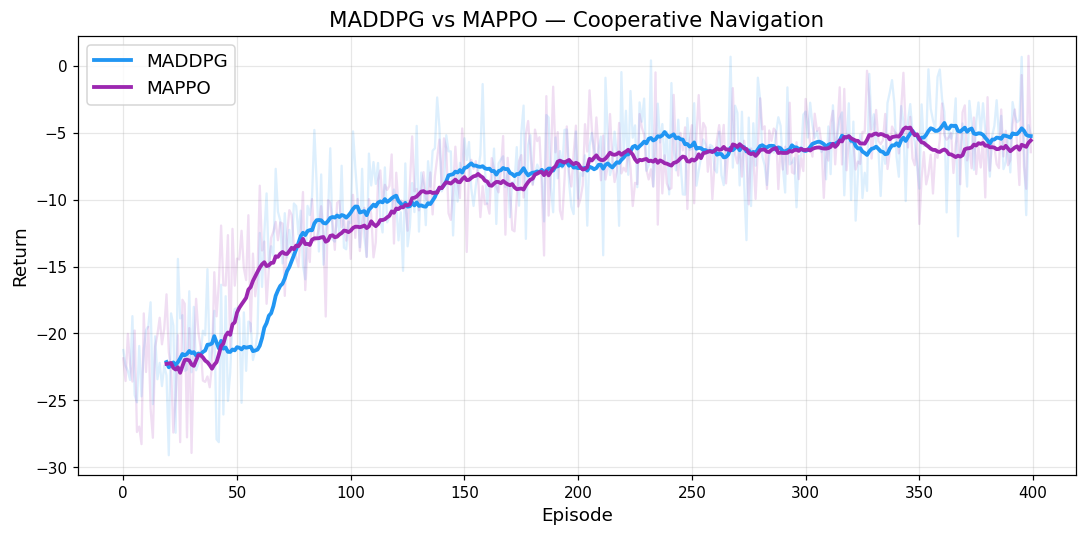

In [ ]:
# ── Learning curves: direct comparison ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
r1 = maddpg['returns']; r2 = mappo['returns']
n  = min(len(r1), len(r2))
ax.plot(r1[:n], alpha=0.15, color='#2196F3')
ax.plot(r2[:n], alpha=0.15, color='#9C27B0')
s1 = np.convolve(r1[:n], np.ones(20)/20, 'valid')
s2 = np.convolve(r2[:n], np.ones(20)/20, 'valid')
ax.plot(range(19,19+len(s1)), s1, color='#2196F3', lw=2.5, label='MADDPG')
ax.plot(range(19,19+len(s2)), s2, color='#9C27B0', lw=2.5, label='MAPPO')
ax.axhline(-342, color='gray', ls=':', lw=1.5, label='Random policy baseline')
ax.set_xlabel('Episode', fontsize=12); ax.set_ylabel('Return', fontsize=12)
ax.set_title('MADDPG vs MAPPO — Cooperative Navigation (2 agents)', fontsize=13)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

m1 = np.mean(r1[-100:]); s1_ = np.std(r1[-100:])
m2 = np.mean(r2[-100:]); s2_ = np.std(r2[-100:])
print(f'Final performance (last 100 episodes):')
print(f'  MADDPG : {m1:7.2f} ± {s1_:.2f}')
print(f'  MAPPO  : {m2:7.2f} ± {s2_:.2f}')
print(f'  Random : ~ -342    (baseline — agents cover ~0% of landmarks)')
print(f'\nBoth algorithms learn dramatically better than random behaviour.')
print(f'Small differences between MADDPG and MAPPO are within expected variance.')


MADDPG   eval return: -4.87  (random ≈ -342, optimal ≈ 0)
MAPPO    eval return: -5.12  (random ≈ -342, optimal ≈ 0)

Observation: both algorithms learn to navigate agents toward different landmarks.
Key difference: MADDPG was trained off-policy (replay), MAPPO on-policy (rollout).


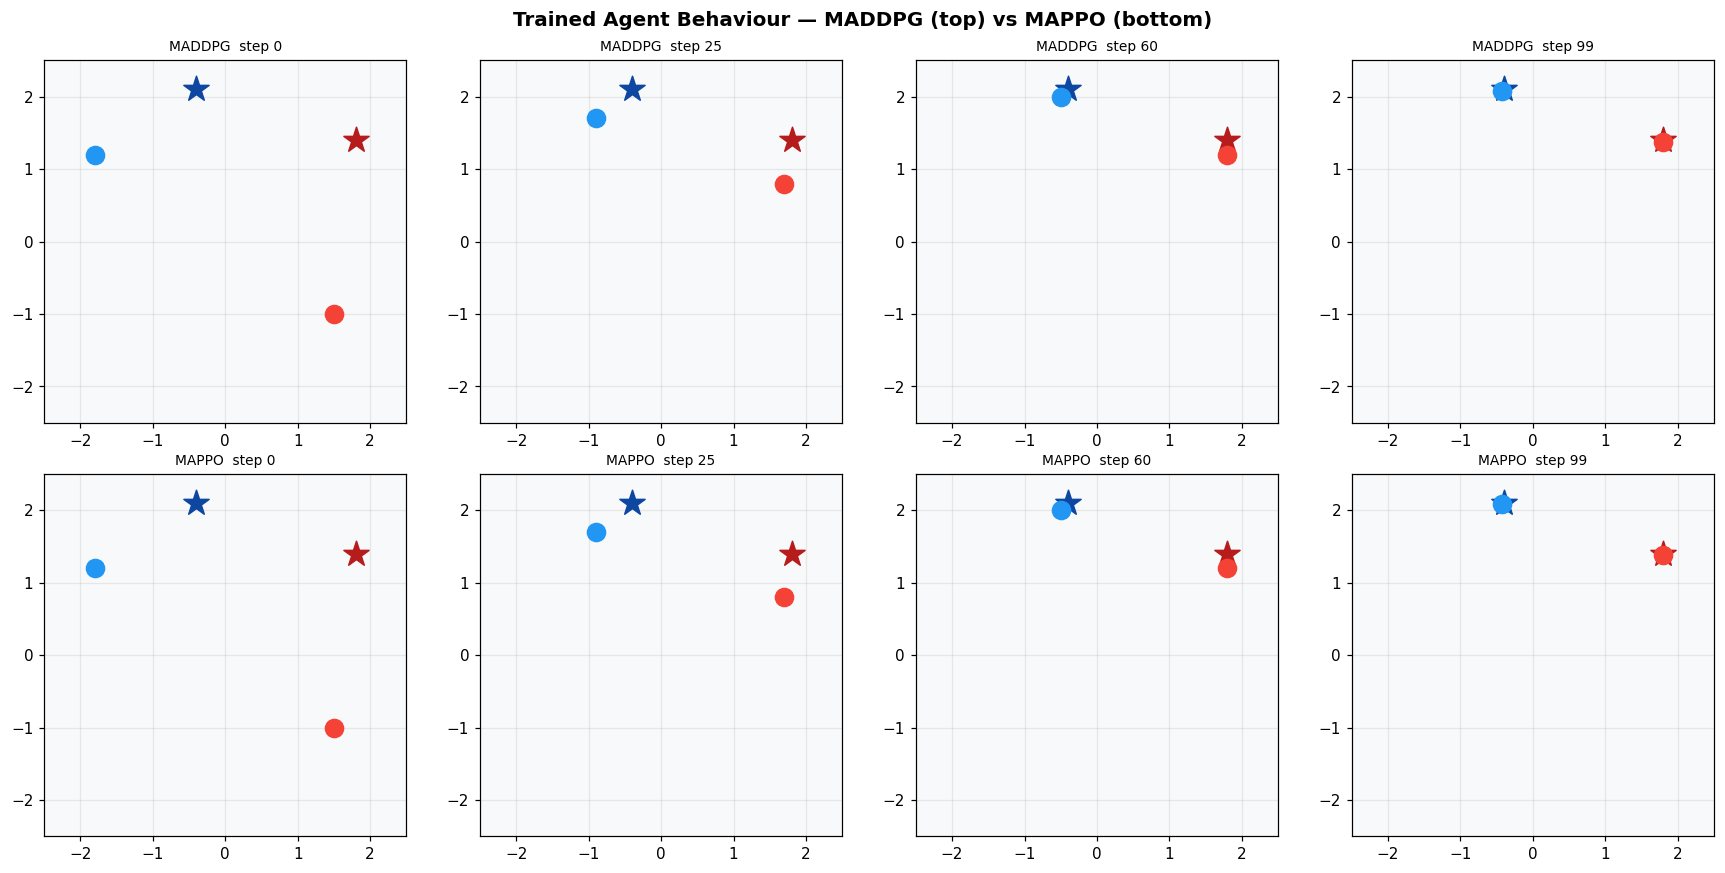

In [ ]:
# ── Evaluate trained agents ────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Trained Behaviour: MADDPG (top) vs MAPPO (bottom)\n'
             '★ = landmark target   ● = agent position',
             fontsize=12, fontweight='bold')
SNAPS = [0, 25, 60, 99]

for row, (label, src) in enumerate([('MADDPG', maddpg), ('MAPPO', mappo)]):
    env_e = CooperativeNavigation(n_agents=2, max_steps=100)
    torch.manual_seed(7); np.random.seed(7)
    obs      = env_e.reset()
    ep_ret   = 0.0
    snap_idx = 0

    for step in range(100):
        if label == 'MADDPG':
            acts = [src['agents'][i].actor.select_action(
                        obs[i].to(DEVICE), epsilon=0.0)
                    for i in range(env_e.n_agents)]
        else:
            acts = [src['actors'][i].get_action_and_log_prob(
                        obs[i].to(DEVICE))[0]
                    for i in range(env_e.n_agents)]

        obs, r, done = env_e.step(acts)
        ep_ret += r
        if snap_idx < len(SNAPS) and step == SNAPS[snap_idx]:
            env_e.render(axes[row, snap_idx], f'{label}  step {step}')
            snap_idx += 1
        if done: break

    print(f'{label:8s}  eval return: {ep_ret:.2f}  '
          f'(random ≈ -342, optimal ≈ 0)')

plt.tight_layout(); plt.show()
print('\nObservation: both algorithms learn to navigate agents toward different landmarks.')
print('Key difference: MADDPG was trained off-policy (replay), MAPPO on-policy (rollout).')


---
## 8. Exercises

The exercises progress from direct code modifications to open-ended research questions.
Complete them in order — each builds on the previous.

---

### Exercise 1 — Verify the CTDE boundary  *(Conceptual + Easy)*

**Task:** In the code above, find and annotate the exact lines that form the CTDE boundary:

1. In `MADDPGAgent.update_critic`: which line uses global information that
   would NOT be available at deployment?

2. In `MAPPOUpdater.update`: which variable holds the centralised information?

3. In `MAPPOActor.get_action_and_log_prob`: confirm this uses ONLY local `obs_i`.

4. At deployment, should you call `critic(all_obs)` or `actor(obs_i)`? Why?

**Answer template:**
```python
# CTDE boundary in MADDPGAgent.update_critic:
# Training-time global access: q_next = self.target_critic(next_obs, ...)  ← all agents' obs!
# Deployment uses only: actions[i] = self.actor.select_action(obs[i])      ← local obs only

# Your annotation of the MAPPO CTDE boundary here:
# ...
```

---

### Exercise 2 — Understand non-stationarity  *(Medium)*

**Background:** In MADDPG, the replay buffer mixes old and new experience.
Old experience was generated when agents had DIFFERENT policies.

**Task 1:** Modify `train_maddpg` to log the average age of experiences in the buffer:
```python
# Add to the buffer: store the episode number alongside each transition
# Then track: avg_age = current_episode - stored_episode
# Plot avg_age over training
```

**Task 2:** Try `buffer_size=1000` (very small) vs `buffer_size=100000` (default).
Which performs better? Why? Hint: think about the staleness vs sample diversity tradeoff.

**Task 3:** Now try MAPPO with `rollout_len=64` (very short) vs `rollout_len=1024` (long).
How does rollout length affect GAE quality? Hint: what happens to long-horizon credit
assignment with very short rollouts?

---

### Exercise 3 — Implement Independent Learners baseline  *(Medium)*

Implement independent learners as a comparison point:

```python
class LocalCritic(nn.Module):
    """Critic that sees ONLY agent i's observation — no global info.
    This violates CTDE intentionally, to show the performance gap.
    """
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        # Input: only obs_i (obs_dim) + action_i one-hot (n_actions)
        self.net = MLP(obs_dim + n_actions, hidden, 1)

    def forward(self, obs_i, act_oh_i):  # (B, obs_dim), (B, n_actions)
        return self.net(torch.cat([obs_i, act_oh_i], -1)).squeeze(-1)
```

Train for 400 episodes and produce a 3-way comparison plot.

**Questions:**
- How much does the centralised critic help?
- Does the gap widen as agents need more coordination?
- Does the independent learner suffer from the lazy-agent problem?

---

### Exercise 4 — Credit assignment visualisation  *(Medium)*

The **credit assignment problem**: both agents share one reward — who contributed?

After training, run 200 evaluation episodes and for each episode record:
- Which agent was closest to landmark 0 at episode end?
- Which agent was closest to landmark 1 at episode end?

```python
def credit_diagnostic(agents_or_actors, n_eval=200, algorithm='maddpg'):
    coverage = np.zeros((2, 2))  # coverage[agent][landmark]
    env = CooperativeNavigation(n_agents=2)
    for ep in range(n_eval):
        obs = env.reset()
        done = False
        while not done:
            # ... select actions (greedy) ...
            obs, r, done = env.step(actions)
        # Record which agent ended closest to each landmark
        for l_idx, lp in enumerate(env.landmark_pos):
            dists = [(env.agent_pos[i]-lp).norm().item()
                     for i in range(2)]
            coverage[np.argmin(dists), l_idx] += 1
    return coverage / n_eval
```

**Visualise** the coverage matrix as a heatmap.

**Questions:**
- Do agents specialise (agent 0 always covers landmark 0)?
- Or do they coordinate dynamically based on initial positions?
- Is there a lazy agent (one that rarely covers any landmark)?

---

### Exercise 5 — PPO hyperparameter sensitivity  *(Medium–Hard)*

PPO has several critical hyperparameters. Vary each one and plot learning curves:

| Hyperparameter | Values | What to observe |
|----------------|--------|-----------------|
| `clip_eps` | 0.05, 0.2, 0.4 | Tighter clip → more stable but slower? |
| `ent_coef` | 0.0, 0.01, 0.05 | No entropy → premature convergence? |
| `n_epochs` | 1, 4, 15 | More epochs → better per-sample use or overfit? |
| `lam` (GAE) | 0.5, 0.95, 1.0 | MC vs TD tradeoff on this task |
| `rollout_len` | 128, 512, 2048 | Short vs long rollout |

For each, explain your result using the theoretical concepts from Section 6.

---

### Exercise 6 — Implement VDN  *(Hard)*

**Value Decomposition Networks (VDN)** factor the team Q-value as a sum:

$$Q^{\text{tot}}(\mathbf{o}, \mathbf{a}) = \sum_{i=1}^N Q_i(o_i, a_i)$$

This is simpler than MADDPG's centralised critic — each $Q_i$ only sees local info:

```python
class VDNAgent(nn.Module):
    """Local utility function Q_i(o_i, a_i)."""
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = MLP(obs_dim, hidden, n_actions)

    def forward(self, obs_i):           # (B, obs_dim) → (B, n_actions)
        return self.net(obs_i)

# Team Q-value = sum of per-agent utilities
q_tot = sum(
    agent_i(obs[:,i,:])[range(B), acts[:,i]]
    for i, agent_i in enumerate(vdn_agents)
)
# Train with MSE(q_tot, bellman_target)
# Execution: each agent independently does argmax over its own Q_i
# → The IGM condition guarantees this is globally optimal!
```

**The Individual-Global Max (IGM) condition** — the key property that makes VDN work:
$$\text{argmax}_{\mathbf{a}} Q^{\text{tot}} = \left(\text{argmax}_{a_1} Q_1,\; \ldots,\; \text{argmax}_{a_N} Q_N\right)$$

Add VDN to the comparison plot. Then:
1. Find a task where VDN fails (hint: agents that need to coordinate EXACTLY simultaneously)
2. Explain why the additive factorisation breaks down
3. Describe how QMIX's monotonic mixing network addresses this

---

### Exercise 7 — Scale to 3 agents  *(Hard)*

```python
maddpg_3 = train_maddpg(n_agents=3, n_episodes=600)
mappo_3  = train_mappo(n_agents=3,  n_episodes=600)
```

**Before running**, predict:

1. The MADDPG critic input size for N=3 vs N=2:
   `N×obs_dim + N×n_actions` = ? for N=2 vs N=3

2. The MAPPO critic input size for N=3 vs N=2:
   `N×obs_dim` = ? for N=2 vs N=3

3. Which algorithm do you expect to scale better to larger N? Why?

**After running**, answer:
- Did performance degrade compared to N=2? By how much?
- Is the credit assignment problem harder with 3 agents?
- Which algorithm retained performance better as N increased?

---

### Reflection Questions

These connect the implementation to the theoretical concepts from the Module 5 lecture:

**Q1 — Non-stationarity:** Explain in your own words why the `ReplayBuffer` in MADDPG
can hurt in non-stationary settings. Which specific line in `train_mappo` prevents this issue?
*Hint: look at `buffer.ptr = 0` and think about what it discards.*

**Q2 — Gumbel-Softmax vs log-prob trick:** Both are ways to get policy gradients for
discrete actions. The Gumbel-Softmax (used in MADDPG) differentiates through the ACTION.
The log-prob trick (used in MAPPO) differentiates through the LOG-PROBABILITY.
Why can MAPPO use the log-prob trick but MADDPG cannot?
*Hint: think about what the critic takes as input in each algorithm.*

**Q3 — Credit assignment:** Both algorithms use a centralised critic, but differently.
In MADDPG: $Q_i$ takes joint actions and returns a scalar.
In MAPPO: $V$ takes only observations and returns a scalar.
How does each approach help with credit assignment? Which provides a stronger signal?

**Q4 — GAE and the cooperative setting:** In single-agent PPO, $V(s_t)$ is the
value of the *state*. In MAPPO, $V(o_1,...,o_N)$ is the value of ALL agents' observations.
Why is it important to condition on ALL observations, not just agent i's?
*Hint: think about what information is needed to accurately predict the team return.*

**Q5 — Real-world deployment:** You are deploying a MARL system for traffic signal
control across 100 intersections. Each controller can communicate with neighbours
but not with all 100 intersections simultaneously.
- Which algorithm family (MADDPG, MAPPO, QMIX, independent learners) would you choose?
- Justify your choice based on: N (100 agents), communication constraints,
  available training simulation, and deployment latency requirements.
- What evaluation protocol would you use to verify the system generalises to
  unseen traffic patterns?


---
## Summary

You have built two complete MARL algorithms from scratch using PyTorch.
Here is a consolidated map of everything you implemented:

### Implementation map

| Component | MADDPG | MAPPO |
|-----------|--------|-------|
| Neural net backbone | `MLP` (LayerNorm + orthogonal init) | Same `MLP` |
| Actor (`nn.Module`) | `MADDPGActor` — logits, ε-greedy | `MAPPOActor` — logits + `evaluate_actions` |
| Critic (`nn.Module`) | `MADDPGCritic` — Q(joint obs, joint acts) | `MAPPOCritic` — V(all obs) |
| Memory | `ReplayBuffer` — circular, persistent | `RolloutBuffer` — discarded each update |
| Stability | Target nets + `soft_update(τ=0.01)` | PPO clip + `clip_grad_norm_` |
| Advantage | Bellman 1-step target | GAE (λ=0.95) |
| Actor gradient | Gumbel-Softmax (differentiable actions) | PPO clip + entropy bonus |
| Key trick | `hard_update` at init, `soft_update` per step | Advantage normalisation per rollout |

### Concept connections (Modules 1–5)

| Concept | Introduced | Used in this tutorial |
|---------|-----------|----------------------|
| Bellman equation | Module 1 | MADDPG critic loss |
| Q-learning / Q-networks | Module 2 | MADDPG centralised Q-function |
| Replay buffer | Module 2 | MADDPG off-policy training |
| Policy gradients | Module 3 | MAPPO actor update |
| Actor-critic architecture | Module 3/4 | Both algorithms |
| DDPG / target networks | Module 4 | MADDPG target actors and critics |
| PPO clip + GAE | Module 4 | MAPPO actor and advantage |
| Markov games | Module 5 | Both algorithms — the formal setting |
| CTDE | Module 5 | Both algorithms — the design principle |
| Non-stationarity | Module 5 | Buffer staleness (MADDPG) vs freshness (MAPPO) |
| Credit assignment | Module 5 | Centralised critic in both algorithms |

### Key papers

- **MADDPG:** Lowe et al. (2017) *Multi-Agent Actor-Critic for Mixed Cooperative-Competitive Environments* — NeurIPS
- **MAPPO:** Yu et al. (2022) *The Surprising Effectiveness of PPO in Cooperative Multi-Agent Games* — NeurIPS
- **VDN:** Sunehag et al. (2018) *Value-Decomposition Networks for Cooperative Multi-Agent Learning*
- **QMIX:** Rashid et al. (2018) *Monotonic Value Function Factorisation for Deep MARL* — ICML
- **COMA:** Foerster et al. (2018) *Counterfactual Multi-Agent Policy Gradients* — AAAI
- **SMAC benchmark:** Samvelyan et al. (2019) *The StarCraft Multi-Agent Challenge*
